Created 5/8/2022

Want to calculate the out of cluster variance for sir3. 


#need to grab which recall trial it is and then use only trials that have 2 other, calculate out of cluster variance and then do the binning and then plot for both sir3 and sir3_chunk

1) see if all three recall trials are not -1 
2) check which recall trial type it is
3) find varaince of the other two 
4) record the error for that trial type. 
5) bin and plot 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

In [ ]:
#read in relevant 

In [2]:
import scipy.stats
scipy.stats.circvar([360,180], high = 360)

245106.50913797694

In [3]:
np.var([360,180])

8100.0

In [22]:
def CalcOCV(df_recall, stim_diff = 360, var = 'var', df = [], uniform = False):
    stim_diff_half = stim_diff/2
    decodeout = df_recall['#OutDecode']
    target = df_recall['#OutTarget']
    trials = len(df_recall)
    
    err = []
    ocv = []
    mod_lab = []
    trialname = []
    
    for i in range(trials):
        t = df_recall.iloc[i]['$TrialName']
        recall = t.split('Recall')[1].split('_')[0]
        if recall == '1':
            mnt1 = float(t.split('_')[1])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3= float(t.split('mnt3_')[1].split('_')[0])
        if recall=='2':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('_')[1])
            mnt3 = float(t.split('mnt3_')[1].split('_')[0]) 
        if recall=='3':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3 = float(t.split('_')[1])
        
        if uniform:
            ind_r = df_recall.iloc[i]['ind']
            tr = df[df['ind'] == (ind_r-1)]
            t_un = tr['$TrialName'][0]
            #print(t_un)
            mnt1 = float(t_un.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t_un.split('mnt2_')[1].split('_')[0])
            mnt3= float(t_un.split('mnt3_')[1].split('_')[0])
            #print(mnt1)
            #print(mnt2)
            #print(mnt3)

        if mnt1 != -1 and mnt2 != -1 and mnt3 != -1:
            decodeout = df_recall.iloc[i]['#OutDecode']
            target = df_recall.iloc[i]['#OutTarget']
            diff = decodeout-target
            diff_mod = np.mod(diff+stim_diff_half, stim_diff)-stim_diff_half
            err.append(diff_mod)
            mod_lab.append(df_recall.iloc[i]['mod_lab'])
            trialname.append(t)
            
            if recall == '1':
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt3], high = 360))
                elif var == 'diff':
                    ocv.append(np.mod(mnt2-mnt3+stim_diff_half, stim_diff)-stim_diff_half)
            if recall == '2':
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3], high = 360))
                elif var == 'diff':
                    ocv.append(np.mod(mnt1-mnt3+stim_diff_half, stim_diff)-stim_diff_half)
            if recall == '3':
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3], high = 360))
                elif var == 'diff':
                    ocv.append(np.mod(mnt1-mnt2+stim_diff_half, stim_diff)-stim_diff_half)
    #print(ocv)
    #import pdb; pdb.set_trace
    return ocv, err, mod_lab, trialname

def CalcOCVsir4(df_recall, stim_diff = 360, var = 'var'):
    stim_diff_half = stim_diff/2
    decodeout = df_recall['#OutDecode']
    target = df_recall['#OutTarget']
    trials = len(df_recall)
    
    err = []
    ocv = []
    mod_lab = []
    trialname = []
    
    for i in range(trials):
        t = df_recall.iloc[i]['$TrialName']
        recall = t.split('Recall')[1].split('_')[0]
        
        append_rest = False
        
        if recall == '1':
            mnt1 = float(t.split('_')[1])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3= float(t.split('mnt3_')[1].split('_')[0])
            mnt4 = float(t.split('mnt4_')[1].split('_')[0])
            
            if mnt2 != -1 and mnt3 !=-1 and mnt4 != -1: #all stimuli
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt3,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt3,mnt4], high = 360))
                append_rest = True
            elif mnt2 != -1 and mnt3 != -1 and mnt4 == -1: # 3/4 stimuli, no mnt4
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt3], high = 360))
                append_rest = True
            elif mnt2 != -1 and mnt3 == -1 and mnt4 != -1:# 3/4 stimuli, no mnt3
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt4], high = 360))
                append_rest = True
            elif mnt2 == -1 and mnt3 != -1 and mnt4 != -1: # 3/4 stimuli, no mnt2
                if var == 'var':
                    ocv.append(np.var([mnt3,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt3,mnt4], high = 360))
                append_rest = True 
            
        if recall=='2':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('_')[1])
            mnt3 = float(t.split('mnt3_')[1].split('_')[0]) 
            mnt4 = float(t.split('mnt4_')[1].split('_')[0])
            
            
            if mnt1 != -1 and mnt3 !=-1 and mnt4 != -1: #all stimuli
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt3,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3,mnt4], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt3 != -1 and mnt4 == -1: # 3/4 stimuli, no mnt4
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt3 == -1 and mnt4 != -1:# 3/4 stimuli, no mnt3
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt4], high = 360))
                append_rest = True
            elif mnt1 == -1 and mnt3 != -1 and mnt4 != -1: # 3/4 stimuli, no mnt1
                if var == 'var':
                    ocv.append(np.var([mnt3,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt3,mnt4], high = 360))
                append_rest = True 
            
        if recall=='3':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3 = float(t.split('_')[1])
            mnt4 = float(t.split('mnt4_')[1].split('_')[0])
            
            if mnt1 != -1 and mnt2 !=-1 and mnt4 != -1: #all stimuli
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt2,mnt4], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt2 != -1 and mnt4 == -1: # 3/4 stimuli, no mnt4
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt2], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt2 == -1 and mnt4 != -1:# 3/4 stimuli, no mnt2
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt4], high = 360))
                append_rest = True
            elif mnt1 == -1 and mnt2 != -1 and mnt4 != -1: # 3/4 stimuli, no mnt1
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt4], high = 360))
                append_rest = True 
        if recall=='4':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3 = float(t.split('mnt3_')[1].split('_')[0]) 
            mnt4 = float(t.split('_')[1])
            
            if mnt1 != -1 and mnt2 !=-1 and mnt3 != -1: #all stimuli
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt2,mnt3], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt2 != -1 and mnt3 == -1: # 3/4 stimuli, no mnt3
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt2], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt2 == -1 and mnt3 != -1:# 3/4 stimuli, no mnt2
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3], high = 360))
                append_rest = True
            elif mnt1 == -1 and mnt2 != -1 and mnt3 != -1: # 3/4 stimuli, no mnt1
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt3], high = 360))
                append_rest = True 
            #should all 4 be filled or 3/4 or 4/4 is okay - 3/4 or 4/4 is okay. 
        if append_rest == True: 
            decodeout = df_recall.iloc[i]['#OutDecode']
            target = df_recall.iloc[i]['#OutTarget']
            diff = decodeout-target
            diff_mod = np.mod(diff+stim_diff_half, stim_diff)-stim_diff_half
            err.append(diff_mod)
            mod_lab.append(df_recall.iloc[i]['mod_lab'])
            trialname.append(t)
        append_rest = False

    return ocv, err, mod_lab,trialname

def equalObs(x, nbin):
    nlen = len(x)
    return np.interp(np.linspace(0, nlen, nbin + 1),
                     np.arange(nlen),
                     np.sort(x))


def binnedaverage(df,xcol,ycol,binwidth =0.5, mintrial = 0, bins_equal_size = False, nbins = 20, own_bins = []):
    #x is the values that you want to bin over, y is the responses that will be averaged according to, df is the dataframe
    df = df.sort_values(xcol)
    xmin = np.min(df[xcol])
    xmax = np.max(df[xcol])
    #import pdb; pdb.set_trace()
    if len(own_bins) == 0 :
        bins = np.arange(xmin,xmax,binwidth)
        if bins_equal_size:
            bins = equalObs(df[xcol],nbins)
    else:
        bins = own_bins
    #np.digitize(df[x],bins = bins)
    OCVbin  = []
    AbsErrbin = []
    AbsErrvar = []
    lowlim = bins[0]
    for uplim in bins[1:]:
        df_temp = pd.DataFrame() 
        for row in df.iterrows():
            if row[1][xcol]<uplim and row[1][xcol]>=lowlim:
                df_temp = df_temp.append(row[1])
        lowlim = uplim
        
        if len(df_temp) != 0:
            #import pdb; pdb.set_trace()
            TErr = np.mean(df_temp.groupby('mod_lab').apply(np.mean,axis = 0)['AbsoluteError'])
            TOCV= np.mean(df_temp.groupby('mod_lab').apply(np.mean,axis = 0)['logOCV'])
            TErrvar = np.mean(df_temp.groupby('mod_lab').apply(np.var,axis = 0)['AbsoluteError'])
            TOCVvar= np.mean(df_temp.groupby('mod_lab').apply(np.var,axis = 0)['logOCV'])
            if len(df_temp) < mintrial:
                print(df_temp)
                print('excluded')
            else:
                OCVbin.append(TOCV)
                AbsErrbin.append(TErr)
                AbsErrvar.append(TErrvar)
            
        #TErr,TOCV = df_temp.apply(np.mean,axis = 0)
        #TErrvar,OCVvar = df_temp.apply(np.var,axis = 0)
    return OCVbin,AbsErrbin, AbsErrvar
            
#df.apply(checkrow,axis = 1, args = (uplim,xcol, df_temp,df))

    
def checkrow(x,uplim,xcol,df_temp,df):
    if x[xcol]<uplim:
        df_temp = df_temp.append(x)

def plot_title(base):
    #model_name = base.split('workingmemory')[1].split('/')[1] 
    model_name = base.split('/')[1]
    if 'contexp' in base:
        rewardtype = 'Continuous Exponential'
    elif 'RewThresh' in base:
        rewardtype = 'Binary'
    else:
        rewardtype = 'Continuous Linear'
        
    if 'decodedrew' in base:
        rewardfun = 'Decoded'
    else: 
        rewardfun = 'Unit Difference'
        
    if 'NoStimLoc' in base:
        stimloc = ', No Stim Loc'
    else: 
        stimloc = ", Stim Loc Used"
   
    if 'NoIgnore' in base:
        ignore = ', No Ignore Trials'
    else:
        ignore = ''

    if "StimRange0to45" in base:
        stim_dist = ', StimDist Max 45'
    else:
        stim_dist = ""


    title = 'OCV ,' + model_name + ', Reward Function: ' + rewardtype +', ' +rewardfun +stimloc + ignore +stim_dist#+' '+additional_title
    return title

def getfiles(base):
    files = os.listdir(base)
    files = [f for f in files if 'Base.csv' in f]
    full_files = [base+f for f in files if 'EpcLog' not in f]
    return full_files
#model = 0 
def model_labels(trial):
    new_model = []
    for tr in range(len(trial)):
        if tr == 0:
            pass
        else:
            if trial[tr]<trial[tr-1]:
                new_model.append(tr)
    new_model.append(len(trial))
    model = 0
    for i in range(len(new_model)):
        if i==0:
            model_tr = new_model[i]
            model_labels = np.repeat(model,model_tr)
        else:
            model_tr = new_model[i] - new_model[i-1]
            model_labels = np.append(model_labels,np.repeat(model,model_tr))
        model +=1
    
    return model_labels

    


def plot_ocv(base, var = 'var'):
    full_files = getfiles(base)
    p = Precision()
    err = p.mult_models(full_files)
    #plt.hist(err, bins = 50)
    #plt.title('Error Distribution for All Recall Trials')
    #plt.xlabel('Error')
    #plt.ylabel('Frequency')
    #plt.show()
    #p.dat.head()
    #import pdb; pdb.set_trace()
    df_recall = p.dat.loc['True']
    mod_labs = model_labels(np.array(df_recall['|Trial']))
    df_recall['mod_lab'] = mod_labs
    plt.figure()
    OCV,err, mod_lab = CalcOCV(df_recall, var = 'var')
    plt.scatter(OCV,err)
    title = plot_title(base)
    plt.title(title)
    plt.xlabel('Out of cluster Variance')
    
    logOCV = np.log(OCV)
    #n,bins,patches = plt.hist(logOCV, bins = 10)
    Odf = pd.DataFrame({'logOCV': logOCV, 'AbsoluteError':abs(np.array(err)), 'mod_lab':mod_lab})
    Odf = Odf.sort_values('logOCV')
    OCVbin,AbsErrbin, AbsErrvar = binnedaverage(Odf,'logOCV','AbsoluteError')
    
    
    plt.figure()
    #plt.scatter(OCVbin,AbsErrbin)
    stderror = np.sqrt(AbsErrvar)/np.sqrt(len(full_files))
    plt.errorbar(OCVbin, AbsErrbin, yerr=stderror, fmt="o")
    plt.xlabel('log(OCV)')
    plt.ylabel('Absolute Error')
    title = plot_title(base)
    plt.title('OCV Related to Performance \n'+title)
    plt.show()
    
def plot_ocv_two(base1,base2, var = 'var', mintrial = 0, chunkdf_recall= [],nochunkdf_recall= [], uniform = False, df_chunk  = [], df_nochunk = [], bins_equal_size = False, nbins = 20, own_bins = []):
    if "chunk" in base1: 
        chunk_file = base1
        file = base2
    elif "chunk" in base2:
        chunk_file = base2
        file = base1
    
    if len(chunkdf_recall) == 0:
        full_files = getfiles(chunk_file)
        p = Precision()
        #if len(bad)>0

        err = p.mult_models(full_files)
        df = p.dat
        df['ind'] = range(len(df))
        df_recall = df.loc['True']
        #df_recall = p.dat.loc['True']
    else:
        df_recall = chunkdf_recall
    mod_labs = model_labels(np.array(df_recall['|Trial']))
    df_recall['mod_lab'] = mod_labs
    #return df_recall
    if len(df_chunk) == 0:
        df_chunk= df
    
    if 'sir3' in base1:
        if uniform:
            OCV,err, mod_lab,trialname = CalcOCV(df_recall, var = var, uniform = True, df = df_chunk)
        else:
            OCV,err, mod_lab,trialname = CalcOCV(df_recall, var = var)
            
    elif 'sir4' in base1: 
        OCV,err, mod_lab,trialname = CalcOCVsir4(df_recall, var = var)
        
    logOCV = np.log(np.abs(OCV))
    #logOCV = np.abs(OCV)
    #print('using OCV not logOCV')
    #logOCV = OCV
    #n,bins,patches = plt.hist(logOCV, bins = 10)
    

    
    Odf = pd.DataFrame({'logOCV': logOCV, 'AbsoluteError':abs(np.array(err)), 'mod_lab':mod_lab,'TrialName': trialname})
    Odf = Odf.sort_values('logOCV')
    
    #import pdb; pdb.set_trace()
    plt.figure()
    plt.scatter(Odf['logOCV'],Odf['AbsoluteError'])
    plt.title('Chunk Model')
    #print(Odf)
    chunk_OCVbin,chunk_AbsErrbin, chunk_AbsErrvar = binnedaverage(Odf,'logOCV','AbsoluteError', mintrial = mintrial,bins_equal_size = bins_equal_size, nbins = nbins,own_bins = own_bins)
    
    chunkOCV = OCV
    chunkOdf = Odf
    chunkdf_recall = df_recall
    
    
    if len(nochunkdf_recall)== 0:
        full_files = getfiles(file)
        p = Precision()
        err = p.mult_models(full_files)
        #df_recall = p.dat.loc['True']
        df = p.dat
        df['ind'] = range(len(df))
        df_recall = df.loc['True']
    else:
        df_recall = nochunkdf_recall
    
    if len(df_nochunk) == 0:
        df_nochunk= df
    mod_labs = model_labels(np.array(df_recall['|Trial']))
    df_recall['mod_lab'] = mod_labs

    if 'sir3' in base1:
        if uniform:
            OCV,err, mod_lab,trialname = CalcOCV(df_recall, var = var, uniform = True, df = df_nochunk)
        else:
            OCV,err, mod_lab,trialname = CalcOCV(df_recall, var = var)
    elif 'sir4' in base1:
        OCV,err, mod_lab,trialname = CalcOCVsir4(df_recall, var = var)
    logOCV = np.log(np.abs(OCV))
    #logOCV = np.abs(OCV)
    #print('using OCV not logOCV')
    #logOCV = OCV
    #n,bins,patches = plt.hist(logOCV, bins = 10)

    Odf = pd.DataFrame({'logOCV': logOCV, 'AbsoluteError':abs(np.array(err)), 'mod_lab':mod_lab, 'TrialName': trialname})
    Odf = Odf.sort_values('logOCV')
    
    #plt.figure()
    plt.scatter(Odf['logOCV'],Odf['AbsoluteError'])
    plt.title('Chunk Model')
    nochunk_OCVbin,nochunk_AbsErrbin, nochunk_AbsErrvar = binnedaverage(Odf,'logOCV','AbsoluteError', mintrial = mintrial,bins_equal_size = bins_equal_size, nbins = nbins,own_bins = own_bins)
    
    nochunkOCV = OCV
    nochunkOdf = Odf
    nochunkdf_recall = df_recall
    
    plt.figure()
    #plt.scatter(OCVbin,AbsErrbin)
    if len(chunkdf_recall) ==0:
        num_models = len(full_files)
    else: 
        num_models = 160
    stderror = np.sqrt(chunk_AbsErrvar)/np.sqrt(num_models)
    plt.errorbar(chunk_OCVbin, chunk_AbsErrbin, yerr=stderror, fmt="o")
    
    stderror = np.sqrt(nochunk_AbsErrvar)/np.sqrt(num_models)
    plt.errorbar(nochunk_OCVbin, nochunk_AbsErrbin, yerr=stderror, fmt="o")
    
    plt.xlabel('log(OCV)')
    plt.ylabel('Absolute Error')
    title = plot_title(chunk_file)
    plt.title('OCV Related to Performance \n'+title)
    plt.legend(['Chunk', 'No Chunk'])
    plt.show()
    return chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall
    

    
    

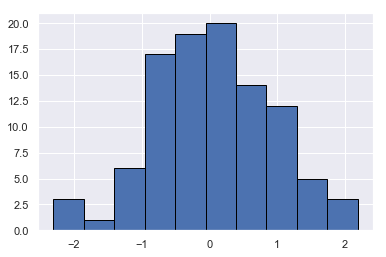

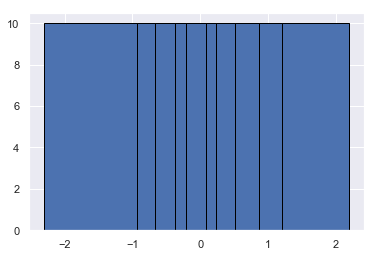

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#create data
np.random.seed(1)
data = np.random.randn(100)

#create histogram with equal-width bins
n, bins, patches = plt.hist(data, edgecolor='black')
plt.show()

#display bin boundaries and frequency per bin 
bins, n


def equalObs(x, nbin):
    nlen = len(x)
    return np.interp(np.linspace(0, nlen, nbin + 1),
                     np.arange(nlen),
                     np.sort(x))

#create histogram with equal-frequency bins 
n, bins, patches = plt.hist(data, equalObs(data, 10), edgecolor='black')
plt.show()

      AbsoluteError                                          TrialName  \
1709            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
1709 -6.490179     68.0  
excluded
      AbsoluteError                                          TrialName  \
382            20.4  Recall3_181.89767746946896_mnt1_145.9900147192...   
1060          134.9  Recall2_224.7360748453479_mnt1_256.43281187897...   
1059          166.9  Recall2_193.68492758357658_mnt1_256.4328118789...   

        logOCV  mod_lab  
382  -5.283909     13.0  
1060 -5.217015     41.0  
1059 -5.217015     41.0  
excluded
      AbsoluteError                                          TrialName  \
1757            0.5  Recall2_217.58110902471998_mnt1_292.0465578503...   

        logOCV  mod_lab  
1757 -3.254783     69.0  
excluded
      AbsoluteError                                          TrialName  \
1814         38.507  Recall3_318.9384209166197_mnt1_11.761349515707...   

        logOCV  mod_l

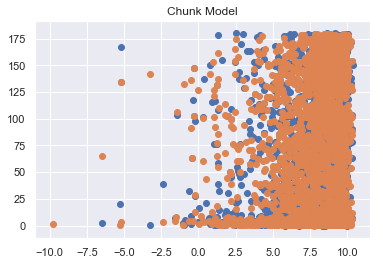

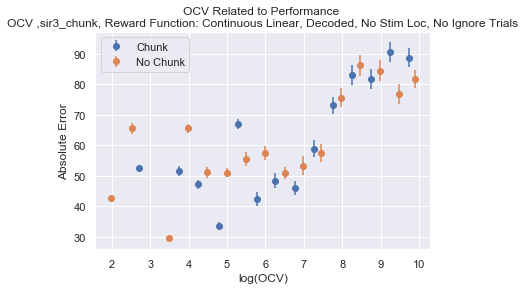

      AbsoluteError                                          TrialName  \
1709            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
1709 -2.551942     68.0  
excluded
      AbsoluteError                                          TrialName  \
382            20.4  Recall3_181.89767746946896_mnt1_145.9900147192...   
1060          134.9  Recall2_224.7360748453479_mnt1_256.43281187897...   
1059          166.9  Recall2_193.68492758357658_mnt1_256.4328118789...   

        logOCV  mod_lab  
382  -1.948807     13.0  
1060 -1.915360     41.0  
1059 -1.915360     41.0  
excluded
      AbsoluteError                                          TrialName  \
1320          150.3  Recall2_146.09286894556652_mnt1_359.9894663360...   

        logOCV  mod_lab  
1320 -1.177709     51.0  
excluded
      AbsoluteError                                          TrialName  \
1757            0.5  Recall2_217.58110902471998_mnt1_292.0465578503...   

        logOCV  mod_l

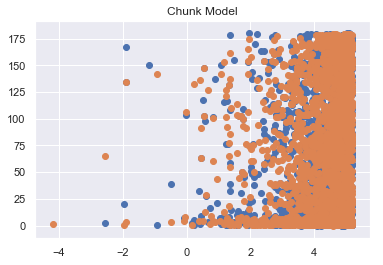

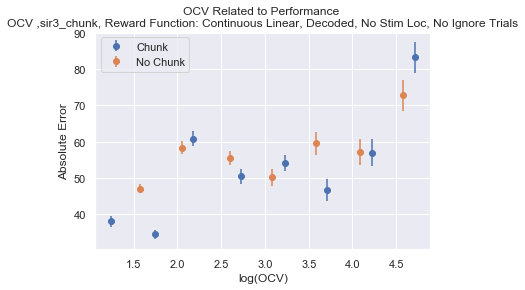

In [20]:
chunk = pd.read_csv('sir3_good_order')
nochunk = pd.read_csv('sir3_good_order_nochunk')
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20, chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = False)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False)

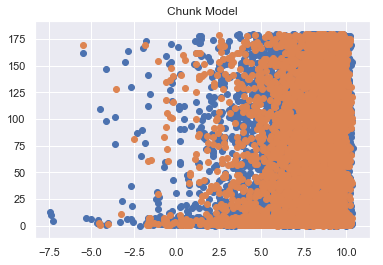

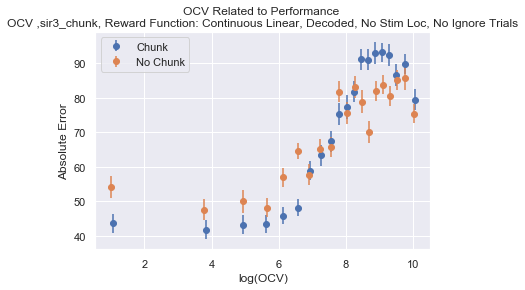

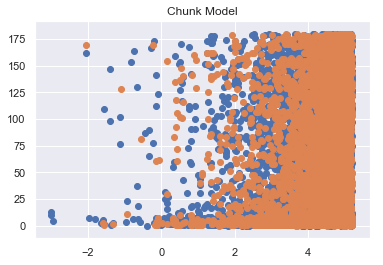

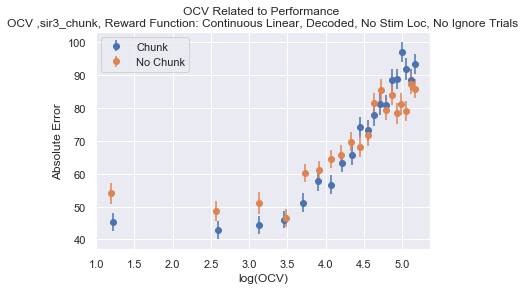

In [39]:
chunk = pd.read_csv('sir3_good_order_moremodels')
nochunk = pd.read_csv('sir3_good_order_moremodels_nochunk')
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0, chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 20)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 20)

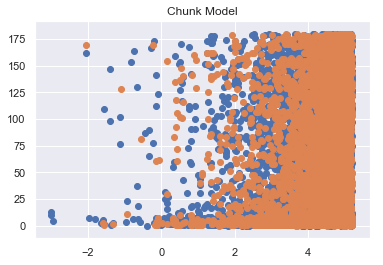

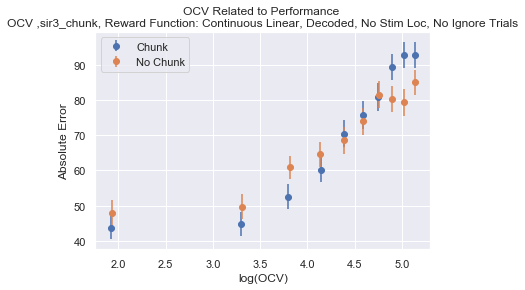

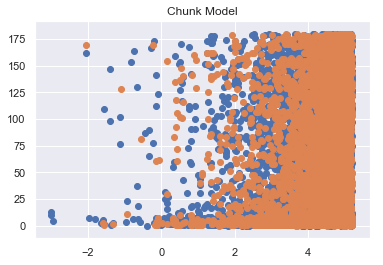

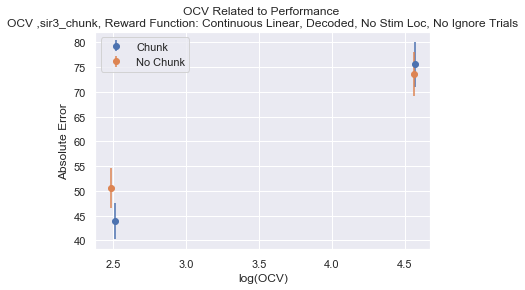

      AbsoluteError                                          TrialName  \
3536          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   
3219          10.00  Recall2_266.10600366187504_mnt1_253.9979080068...   
1975           4.00  Recall2_354.36695005766785_mnt1_190.1624851110...   

        logOCV  mod_lab  
3536 -3.015479     73.0  
3219 -3.003471     67.0  
1975 -2.946642     41.0  
excluded
      AbsoluteError                                          TrialName  \
2430         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

        logOCV  mod_lab  
2430 -2.044319     50.0  
excluded
      AbsoluteError                                          TrialName  \
3388            6.6  Recall3_116.63525060982482_mnt1_131.6730564472...   
2702            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   
7740            2.5  Recall2_253.899931226945_mnt1_138.731778984085...   
7516            5.5  Recall2_222.90596656299218_mnt1_359.2884578970...   
7066      

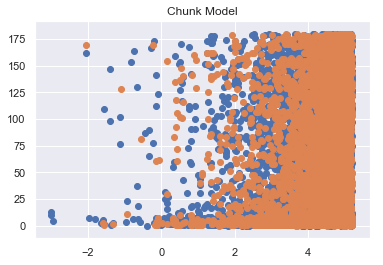

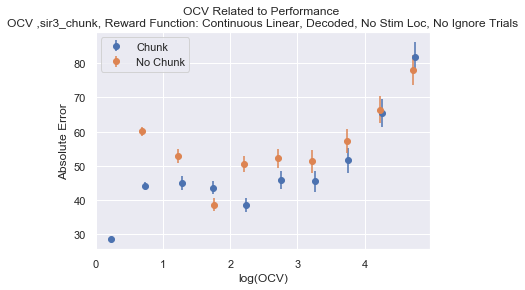

In [40]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 10)
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,own_bins = [-5,3.5, 6])
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False)

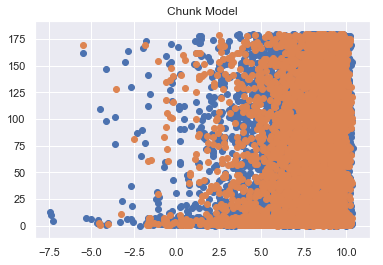

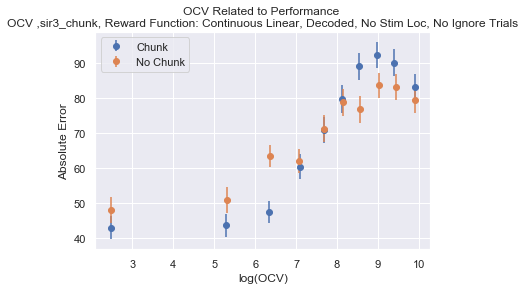

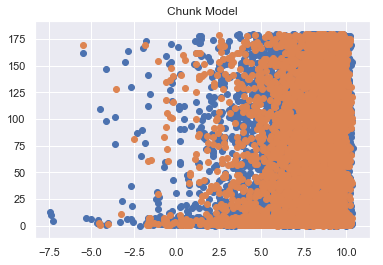

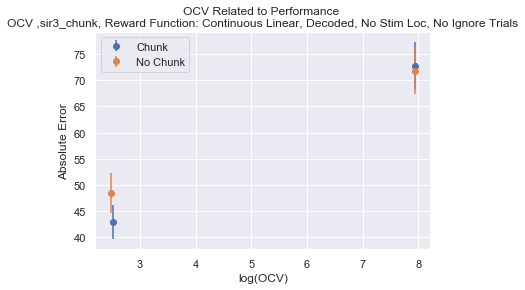

      AbsoluteError                                          TrialName  \
3536          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   
3219          10.00  Recall2_266.10600366187504_mnt1_253.9979080068...   
1975           4.00  Recall2_354.36695005766785_mnt1_190.1624851110...   

        logOCV  mod_lab  
3536 -7.417253     73.0  
3219 -7.393236     67.0  
1975 -7.279578     41.0  
excluded
      AbsoluteError                                          TrialName  \
2430         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

        logOCV  mod_lab  
2430 -5.474933     50.0  
excluded
      AbsoluteError                                          TrialName  \
3388            6.6  Recall3_116.63525060982482_mnt1_131.6730564472...   
2702            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   

        logOCV  mod_lab  
3388 -5.317542     71.0  
2702 -5.001594     56.0  
excluded
      AbsoluteError                                          TrialName

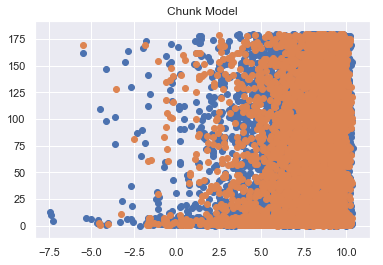

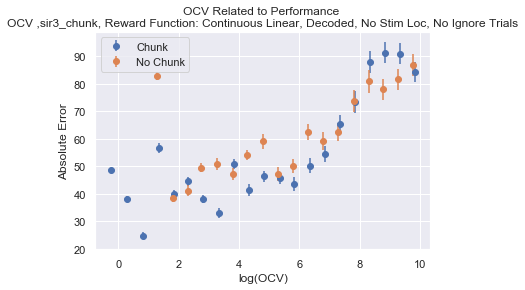

In [41]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 10)
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,own_bins = [-6, 4.5, 11])
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False)

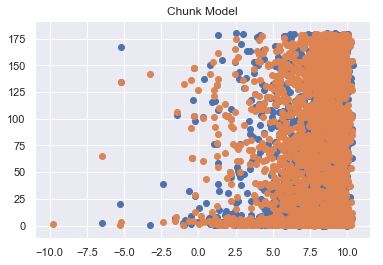

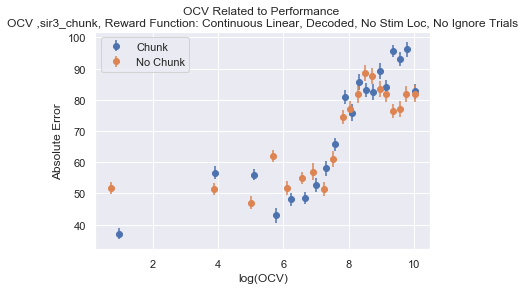

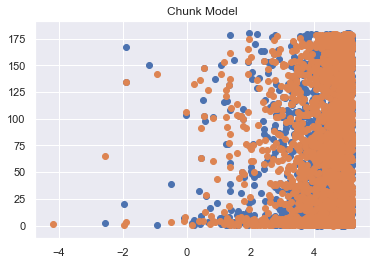

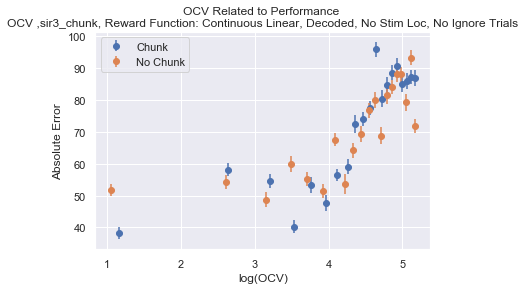

In [31]:
chunk = pd.read_csv('sir3_good_order')
nochunk = pd.read_csv('sir3_good_order_nochunk')
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0, chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 20)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 20)

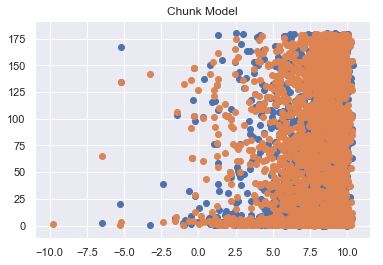

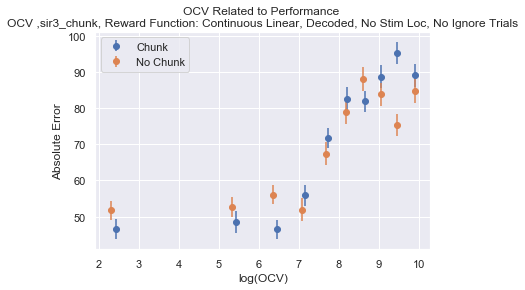

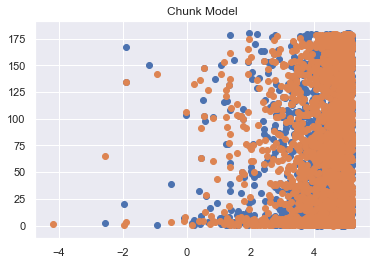

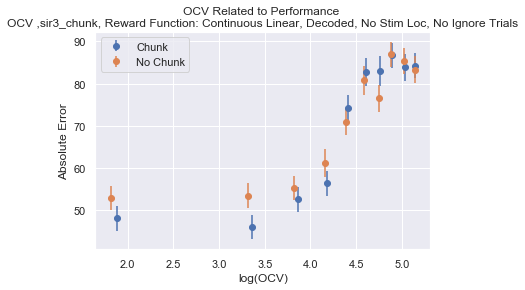

In [32]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0, chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 10)

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 10)

      AbsoluteError                                          TrialName  \
1709            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
1709 -2.551942     68.0  
excluded
      AbsoluteError                                          TrialName  \
382            20.4  Recall3_181.89767746946896_mnt1_145.9900147192...   
1060          134.9  Recall2_224.7360748453479_mnt1_256.43281187897...   
1059          166.9  Recall2_193.68492758357658_mnt1_256.4328118789...   

        logOCV  mod_lab  
382  -1.948807     13.0  
1060 -1.915360     41.0  
1059 -1.915360     41.0  
excluded
      AbsoluteError                                          TrialName  \
1320          150.3  Recall2_146.09286894556652_mnt1_359.9894663360...   

        logOCV  mod_lab  
1320 -1.177709     51.0  
excluded
      AbsoluteError                                          TrialName  \
1757            0.5  Recall2_217.58110902471998_mnt1_292.0465578503...   

        logOCV  mod_l

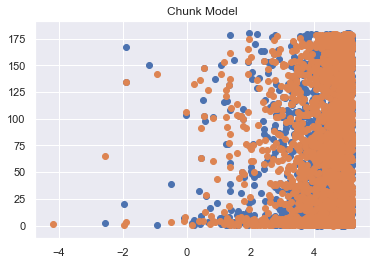

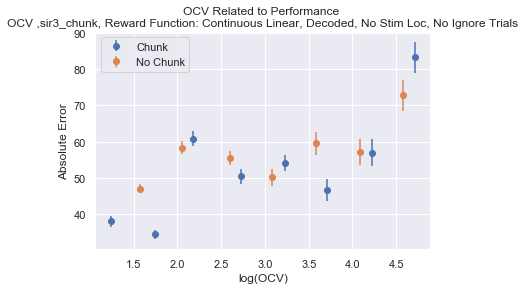

In [38]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False)

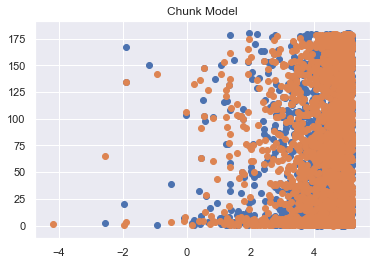

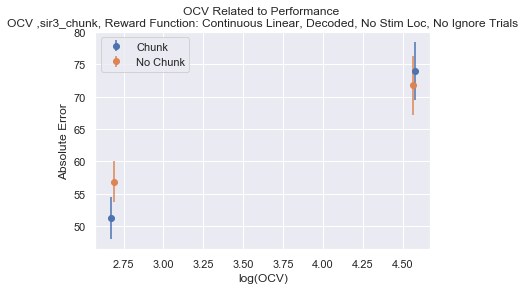

In [37]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,own_bins = [1,3.5,8])

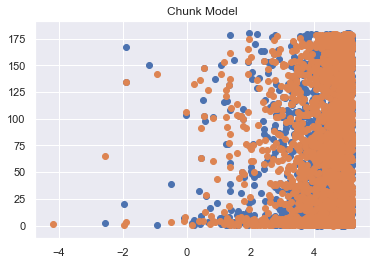

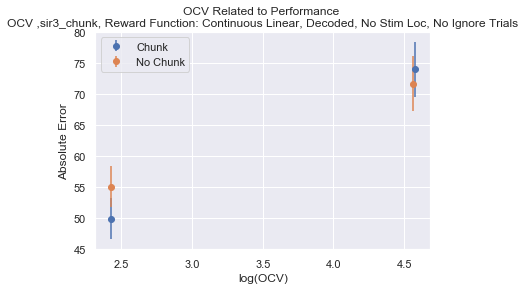

In [33]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,own_bins = [-6,3.5,8])

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:457: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


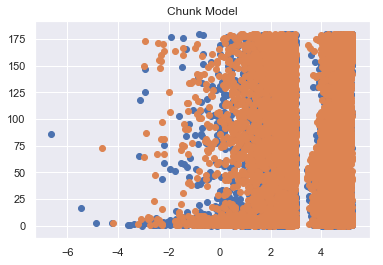

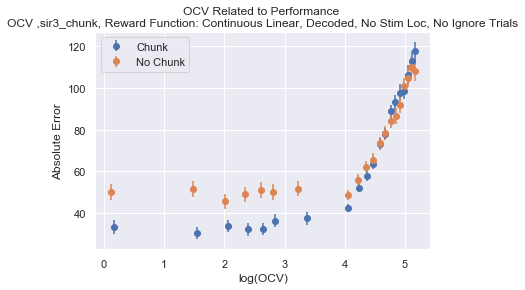

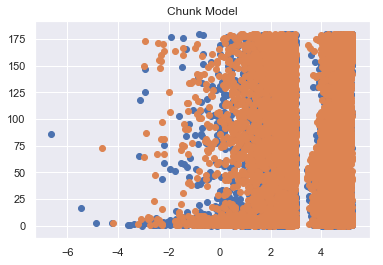

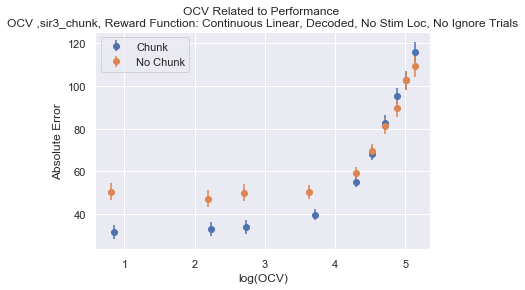

In [43]:

base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/chunktrials/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/chunktrials/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = True,bins_equal_size = True, nbins = 20)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True,bins_equal_size = True, nbins = 10)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:403: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:454: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


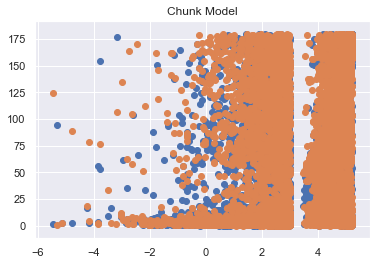

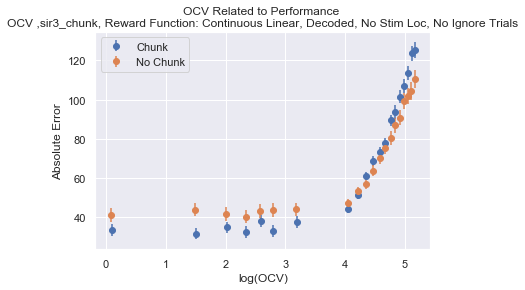

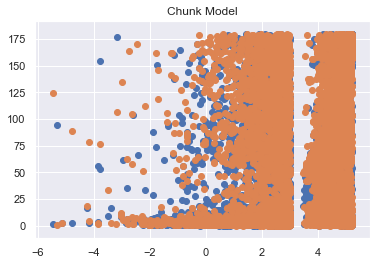

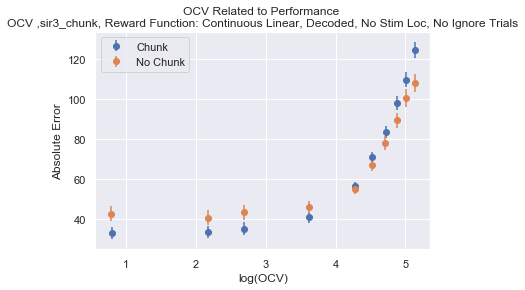

In [16]:

base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = True,bins_equal_size = True, nbins = 20)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True,bins_equal_size = True, nbins = 10)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:403: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:454: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


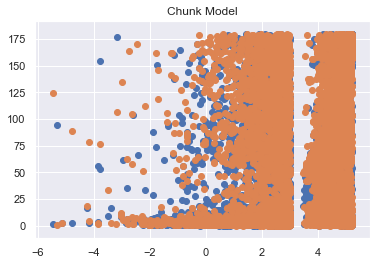

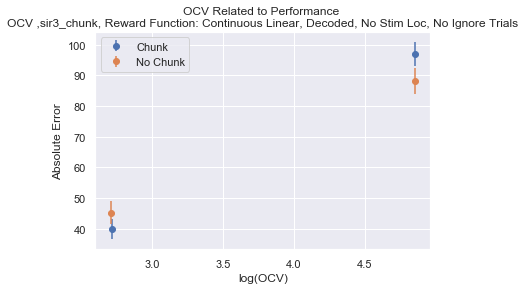

In [17]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True,bins_equal_size = True, nbins = 2)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:403: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:454: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


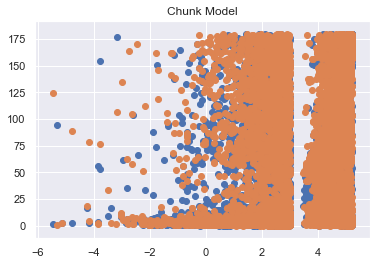

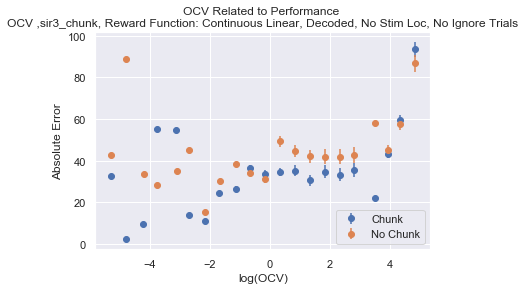

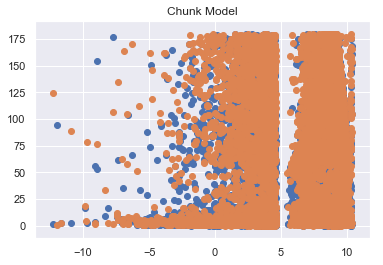

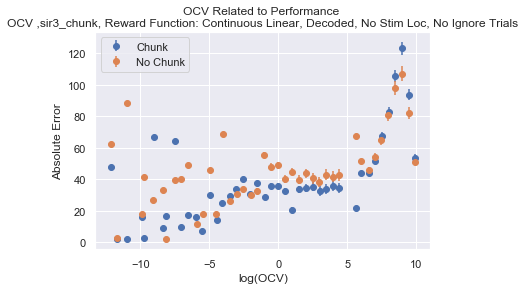

In [18]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True)
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True)


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
2102           1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040          94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            1.9  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:457: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
2102         124.50  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040           0.73  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            2.5  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710           88.6  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           18.1  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

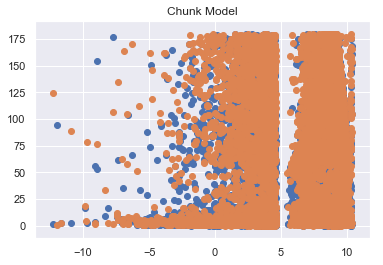

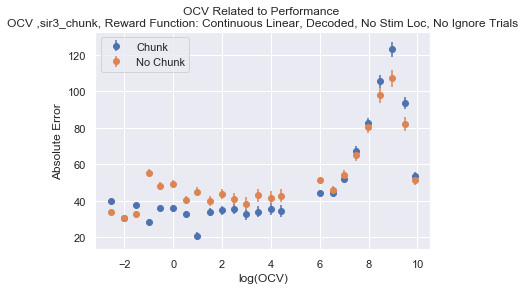

In [24]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 30,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True)


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:457: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


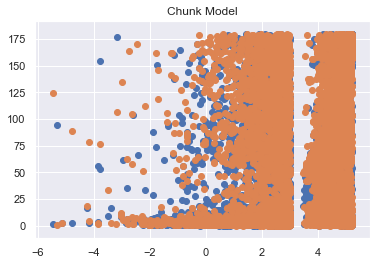

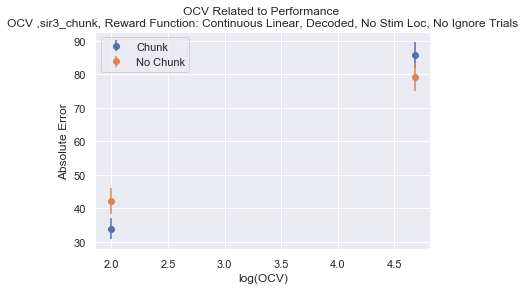

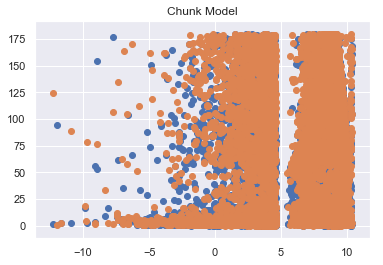

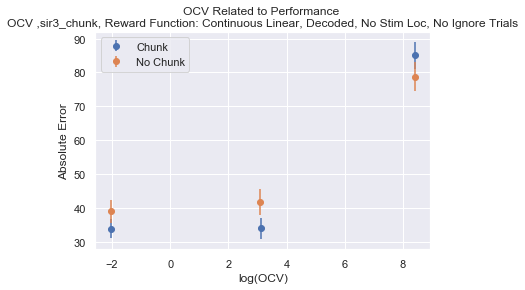

In [30]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True, own_bins = [-6,3.5,6])
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True, own_bins = [-12,0,5,12])


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:457: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


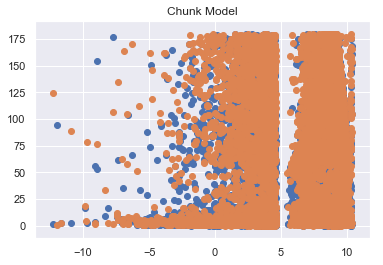

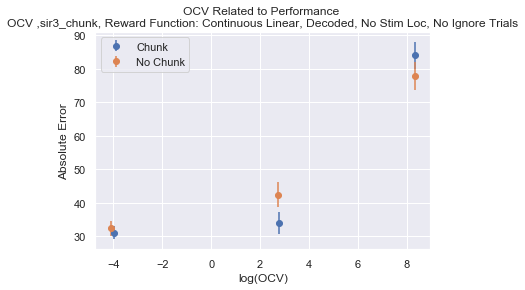

In [26]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True, own_bins = [-12,-2,4.5,12])


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:457: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


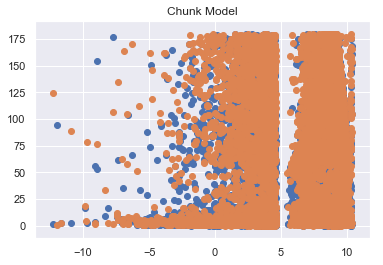

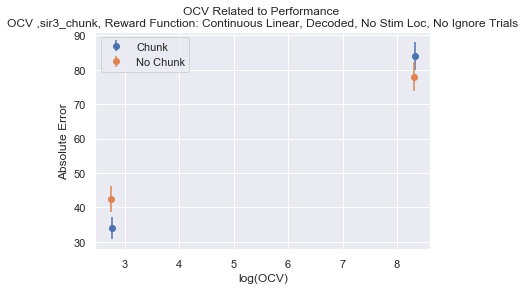

In [27]:
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True, own_bins = [-2,4.5,12])


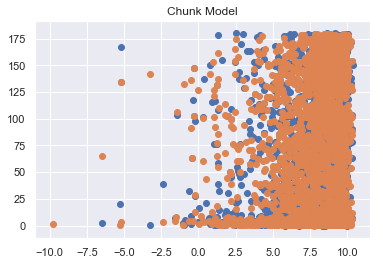

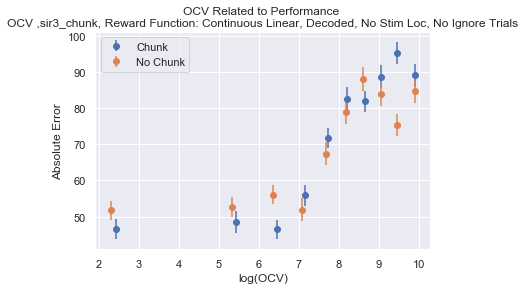

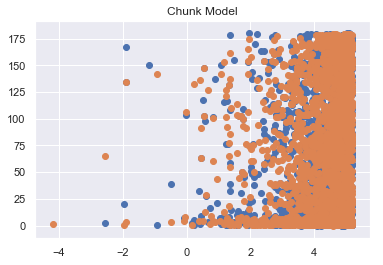

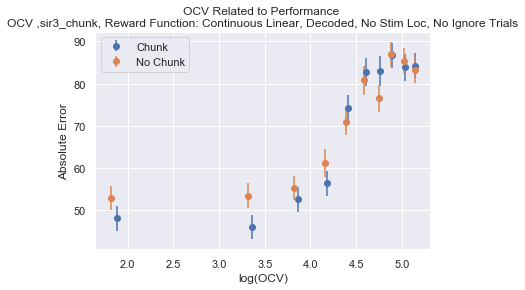

In [23]:
chunk = pd.read_csv('sir3_good_order')
nochunk = pd.read_csv('sir3_good_order_nochunk')
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0, chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 10)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False,bins_equal_size = True, nbins = 10)

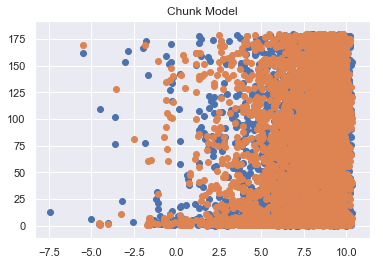

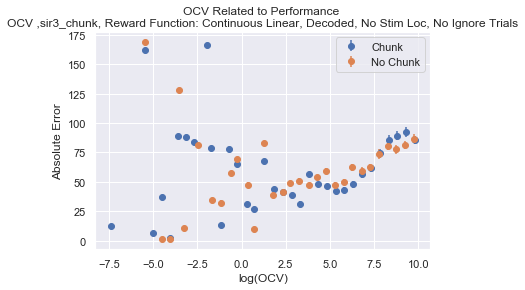

      AbsoluteError                                          TrialName  \
2179          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   

        logOCV  mod_lab  
2179 -7.417253     43.0  
excluded
     AbsoluteError                                          TrialName  \
658         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

       logOCV  mod_lab  
658 -5.474933     13.0  
excluded
      AbsoluteError                                          TrialName  \
1851            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   

        logOCV  mod_lab  
1851 -5.001594     37.0  
excluded
      AbsoluteError                                          TrialName  \
817             1.1  Recall1_329.00494611601073_mnt1_-1_mnt2_275.55...   
2478          109.7  Recall3_108.9488164292292_mnt1_63.845223913032...   
3730            1.8  Recall1_123.16515279930515_mnt1_-1_mnt2_1.6298...   

        logOCV  mod_lab  
817  -4.535253     16.0  
2478 -4.500352     49.0  

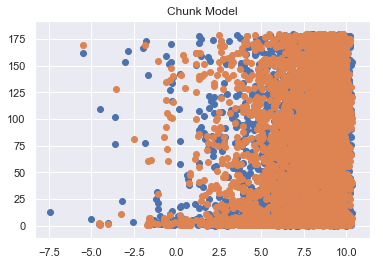

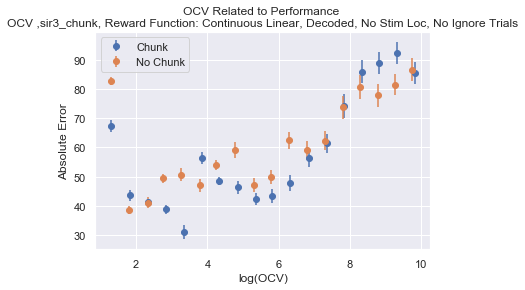

In [11]:
chunk = pd.read_csv('sir3_good_order_moretrials')
nochunk = pd.read_csv('sir3_good_order_moretrials_nochunk')
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0, chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = False)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False)

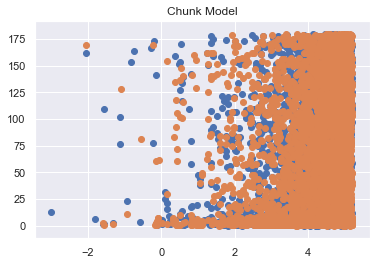

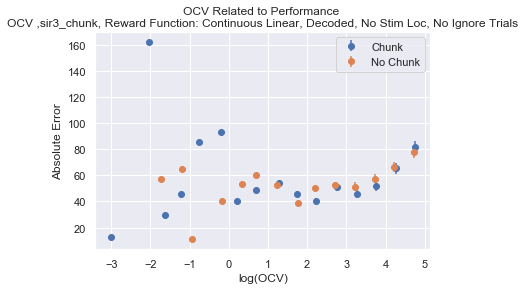

      AbsoluteError                                          TrialName  \
2179          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   

        logOCV  mod_lab  
2179 -3.015479     43.0  
excluded
     AbsoluteError                                          TrialName  \
658         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

       logOCV  mod_lab  
658 -2.044319     13.0  
excluded
      AbsoluteError                                          TrialName  \
1851            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   
817             1.1  Recall1_329.00494611601073_mnt1_-1_mnt2_275.55...   
2478          109.7  Recall3_108.9488164292292_mnt1_63.845223913032...   
3730            1.8  Recall1_123.16515279930515_mnt1_-1_mnt2_1.6298...   

        logOCV  mod_lab  
1851 -1.807650     37.0  
817  -1.574479     16.0  
2478 -1.557029     49.0  
3730 -1.551937     76.0  
excluded
      AbsoluteError                                          TrialName  \


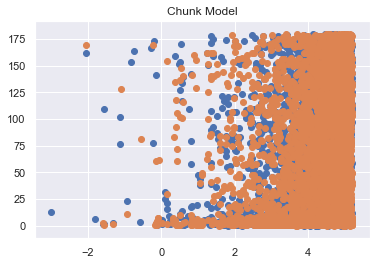

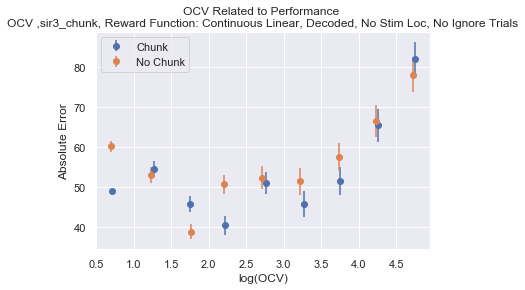

In [14]:
chunk = pd.read_csv('sir3_good_order_moretrials')
nochunk = pd.read_csv('sir3_good_order_moretrials_nochunk')
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = False)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False)

In [ ]:
#try to break the up the bins by equal number of trials; i.e. do the binning by how many trials and then take the average ABE and the average OCV across that bin. 

      AbsoluteError                                          TrialName  \
3536          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   
3219          10.00  Recall2_266.10600366187504_mnt1_253.9979080068...   
1975           4.00  Recall2_354.36695005766785_mnt1_190.1624851110...   

        logOCV  mod_lab  
3536 -3.015479     73.0  
3219 -3.003471     67.0  
1975 -2.946642     41.0  
excluded
      AbsoluteError                                          TrialName  \
2430         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

        logOCV  mod_lab  
2430 -2.044319     50.0  
excluded
      AbsoluteError                                          TrialName  \
3388            6.6  Recall3_116.63525060982482_mnt1_131.6730564472...   
2702            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   
7740            2.5  Recall2_253.899931226945_mnt1_138.731778984085...   
7516            5.5  Recall2_222.90596656299218_mnt1_359.2884578970...   
7066      

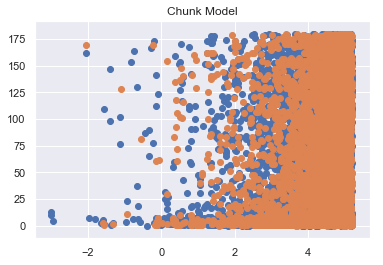

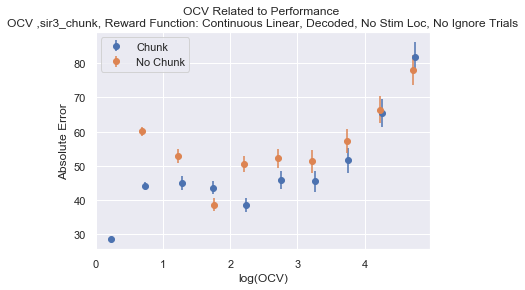

      AbsoluteError                                          TrialName  \
3536          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   
3219          10.00  Recall2_266.10600366187504_mnt1_253.9979080068...   
1975           4.00  Recall2_354.36695005766785_mnt1_190.1624851110...   

        logOCV  mod_lab  
3536 -7.417253     73.0  
3219 -7.393236     67.0  
1975 -7.279578     41.0  
excluded
      AbsoluteError                                          TrialName  \
2430         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

        logOCV  mod_lab  
2430 -5.474933     50.0  
excluded
      AbsoluteError                                          TrialName  \
3388            6.6  Recall3_116.63525060982482_mnt1_131.6730564472...   
2702            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   

        logOCV  mod_lab  
3388 -5.317542     71.0  
2702 -5.001594     56.0  
excluded
      AbsoluteError                                          TrialName

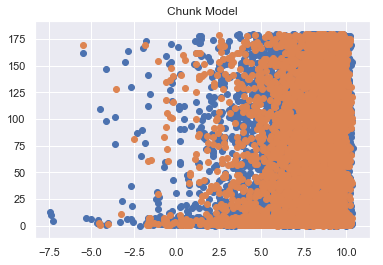

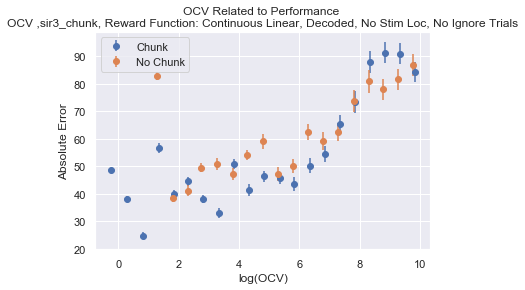

In [4]:
chunk = pd.read_csv('sir3_good_order_moremodels')
nochunk = pd.read_csv('sir3_good_order_moremodels_nochunk')
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

#chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = False)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False)
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:393: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:444: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


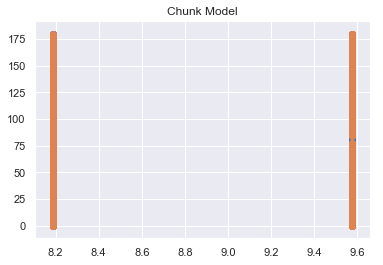

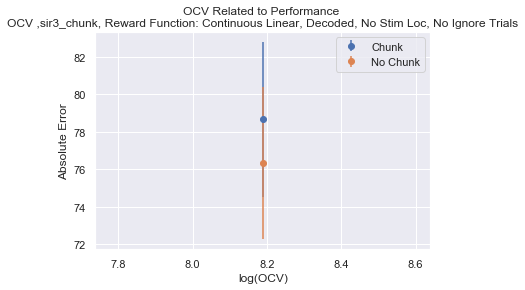

IndexError: index 0 is out of bounds for axis 0 with size 0

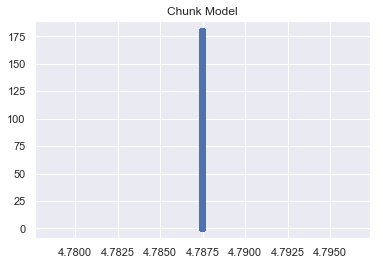

In [15]:

base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/try/uniformtrials/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/try/uniformtrials/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

#chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0, chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = True)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True)

#chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = True)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 20,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = True)

In [ ]:
#chunking trials ocv
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/try/chunktrials/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/try/chunktrials/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

#chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 10, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk, df_nochunk = df_nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk)
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 20, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk)

      AbsoluteError                                          TrialName  \
3536          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   
3219          10.00  Recall2_266.10600366187504_mnt1_253.9979080068...   
1975           4.00  Recall2_354.36695005766785_mnt1_190.1624851110...   

        logOCV  mod_lab  
3536 -7.417253     73.0  
3219 -7.393236     67.0  
1975 -7.279578     41.0  
excluded
      AbsoluteError                                          TrialName  \
2430         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

        logOCV  mod_lab  
2430 -5.474933     50.0  
excluded
      AbsoluteError                                          TrialName  \
3388            6.6  Recall3_116.63525060982482_mnt1_131.6730564472...   
2702            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   

        logOCV  mod_lab  
3388 -5.317542     71.0  
2702 -5.001594     56.0  
excluded
      AbsoluteError                                          TrialName

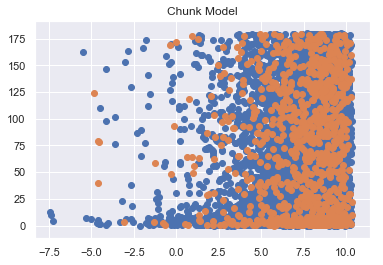

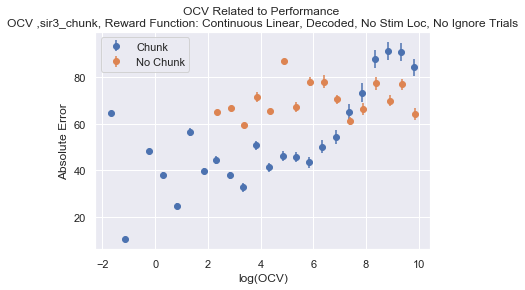

      AbsoluteError                                          TrialName  \
3536          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   
3219          10.00  Recall2_266.10600366187504_mnt1_253.9979080068...   
1975           4.00  Recall2_354.36695005766785_mnt1_190.1624851110...   

        logOCV  mod_lab  
3536 -7.417253     73.0  
3219 -7.393236     67.0  
1975 -7.279578     41.0  
excluded
      AbsoluteError                                          TrialName  \
2430         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

        logOCV  mod_lab  
2430 -5.474933     50.0  
excluded
      AbsoluteError                                          TrialName  \
3388            6.6  Recall3_116.63525060982482_mnt1_131.6730564472...   
2702            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   

        logOCV  mod_lab  
3388 -5.317542     71.0  
2702 -5.001594     56.0  
excluded
      AbsoluteError                                          TrialName

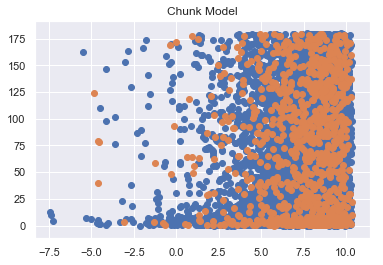

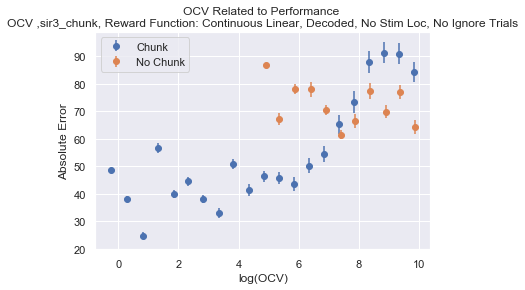

In [5]:
#trying to recreate the ideal/messed up figure
chunk = pd.read_csv('sir3_good_order_moremodels')
nochunk = pd.read_csv('sir3_good_order_moremodels_nochunk')
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"

#need to run this part only once
# full_files = getfiles(base1)
# p = Precision()
# err = p.mult_models(full_files)
# #df_recall = p.dat.loc['True']
# df = p.dat
# df['ind'] = range(len(df))
# df_recall = df.loc['True']
# df_chunk = df

# full_files = getfiles(base2)
# p = Precision()
# err = p.mult_models(full_files)
# #df_recall = p.dat.loc['True']
# df = p.dat
# df['ind'] = range(len(df))
# nocdf_recall = df.loc['True']
# df_nochunk = df

base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 10, uniform = True,chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk, df_nochunk = df_nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20, uniform = True,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk)


      AbsoluteError                                          TrialName  \
3536          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   
3219          10.00  Recall2_266.10600366187504_mnt1_253.9979080068...   
3220          77.80  Recall3_254.04752257146583_mnt1_253.9979080068...   
1975           4.00  Recall2_354.36695005766785_mnt1_190.1624851110...   
1976         170.00  Recall3_190.10996933930997_mnt1_190.1624851110...   

        logOCV  mod_lab  
3536 -7.417253     73.0  
3219 -7.393236     67.0  
3220 -7.393236     67.0  
1975 -7.279578     41.0  
1976 -7.279578     41.0  
excluded
      AbsoluteError                                          TrialName  \
4182           42.3  Recall3_203.53745075006648_mnt1_203.4572656015...   

        logOCV  mod_lab  
4182 -6.433128     88.0  
excluded
      AbsoluteError                                          TrialName  \
2701           78.3  Recall3_139.26240212378568_mnt1_139.3451646346...   
4553            7.6  Recall3_261

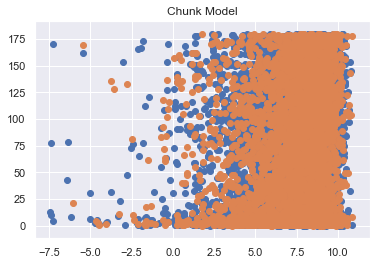

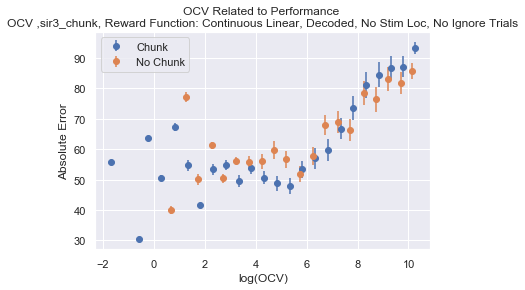

      AbsoluteError                                          TrialName  \
3536          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   
3219          10.00  Recall2_266.10600366187504_mnt1_253.9979080068...   
3220          77.80  Recall3_254.04752257146583_mnt1_253.9979080068...   
1975           4.00  Recall2_354.36695005766785_mnt1_190.1624851110...   
1976         170.00  Recall3_190.10996933930997_mnt1_190.1624851110...   

        logOCV  mod_lab  
3536 -7.417253     73.0  
3219 -7.393236     67.0  
3220 -7.393236     67.0  
1975 -7.279578     41.0  
1976 -7.279578     41.0  
excluded
      AbsoluteError                                          TrialName  \
4182           42.3  Recall3_203.53745075006648_mnt1_203.4572656015...   

        logOCV  mod_lab  
4182 -6.433128     88.0  
excluded
      AbsoluteError                                          TrialName  \
2701           78.3  Recall3_139.26240212378568_mnt1_139.3451646346...   
4553            7.6  Recall3_261

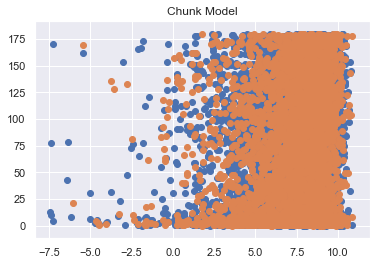

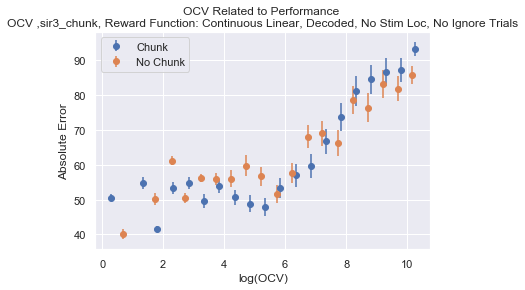

In [21]:
#try circ var
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'circvar',mintrial = 10, chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk,df_nochunk = df_nochunk, uniform = False)
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'circvar',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk, uniform = False)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:393: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
2102           1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040          94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            1.9  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:444: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
2102         124.50  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040           0.73  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            2.5  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710           88.6  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           18.1  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

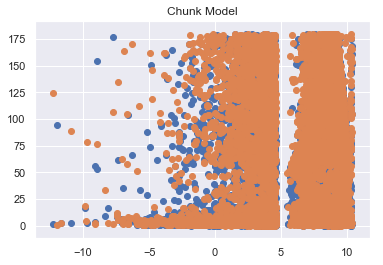

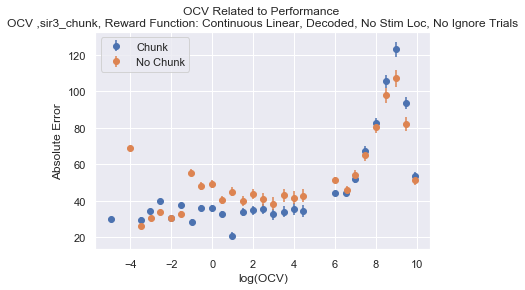

      AbsoluteError                                          TrialName  \
2102           1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040          94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            1.9  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

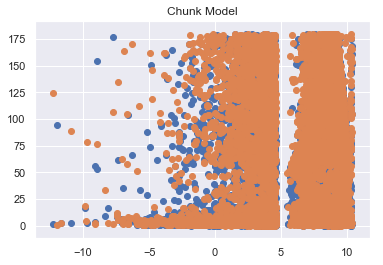

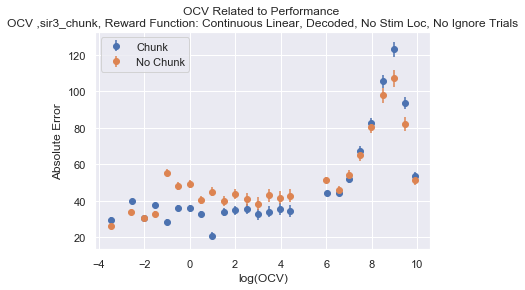

In [6]:
#chunking trials ocv
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 10, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk, df_nochunk = df_nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk)

      AbsoluteError                                          TrialName  \
1709            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
1709 -6.490179     68.0  
excluded
      AbsoluteError                                          TrialName  \
382            20.4  Recall3_181.89767746946896_mnt1_145.9900147192...   
1060          134.9  Recall2_224.7360748453479_mnt1_256.43281187897...   
1059          166.9  Recall2_193.68492758357658_mnt1_256.4328118789...   

        logOCV  mod_lab  
382  -5.283909     13.0  
1060 -5.217015     41.0  
1059 -5.217015     41.0  
excluded
      AbsoluteError                                          TrialName  \
1757            0.5  Recall2_217.58110902471998_mnt1_292.0465578503...   

        logOCV  mod_lab  
1757 -3.254783     69.0  
excluded
      AbsoluteError                                          TrialName  \
1814         38.507  Recall3_318.9384209166197_mnt1_11.761349515707...   

        logOCV  mod_l

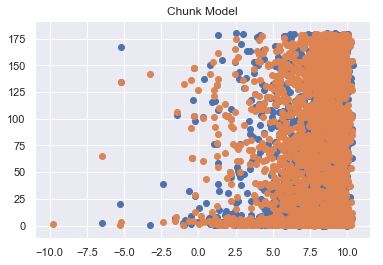

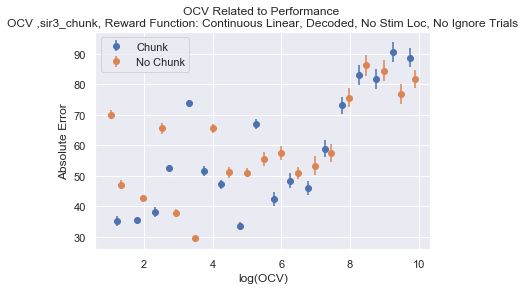

      AbsoluteError                                          TrialName  \
1709            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
1709 -6.490179     68.0  
excluded
      AbsoluteError                                          TrialName  \
382            20.4  Recall3_181.89767746946896_mnt1_145.9900147192...   
1060          134.9  Recall2_224.7360748453479_mnt1_256.43281187897...   
1059          166.9  Recall2_193.68492758357658_mnt1_256.4328118789...   

        logOCV  mod_lab  
382  -5.283909     13.0  
1060 -5.217015     41.0  
1059 -5.217015     41.0  
excluded
      AbsoluteError                                          TrialName  \
1757            0.5  Recall2_217.58110902471998_mnt1_292.0465578503...   

        logOCV  mod_lab  
1757 -3.254783     69.0  
excluded
      AbsoluteError                                          TrialName  \
1814         38.507  Recall3_318.9384209166197_mnt1_11.761349515707...   

        logOCV  mod_l

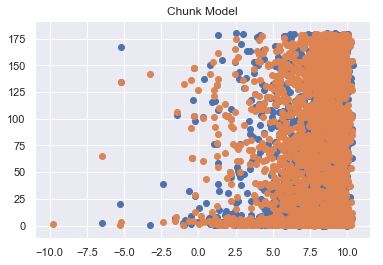

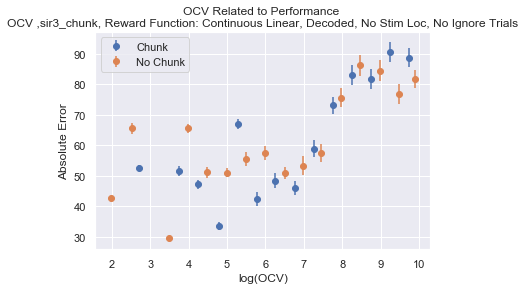

In [7]:
#original number of trials and models, sir3 
chunk = pd.read_csv('sir3_good_order')
nochunk = pd.read_csv('sir3_good_order_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"

# #need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 10, uniform = False,chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk, df_nochunk = df_nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20, uniform = False,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk)

      AbsoluteError                                          TrialName  \
1709            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
1709 -2.551942     68.0  
excluded
      AbsoluteError                                          TrialName  \
382            20.4  Recall3_181.89767746946896_mnt1_145.9900147192...   
1060          134.9  Recall2_224.7360748453479_mnt1_256.43281187897...   
1059          166.9  Recall2_193.68492758357658_mnt1_256.4328118789...   

        logOCV  mod_lab  
382  -1.948807     13.0  
1060 -1.915360     41.0  
1059 -1.915360     41.0  
excluded
      AbsoluteError                                          TrialName  \
1320          150.3  Recall2_146.09286894556652_mnt1_359.9894663360...   

        logOCV  mod_lab  
1320 -1.177709     51.0  
excluded
      AbsoluteError                                          TrialName  \
1757            0.5  Recall2_217.58110902471998_mnt1_292.0465578503...   

        logOCV  mod_l

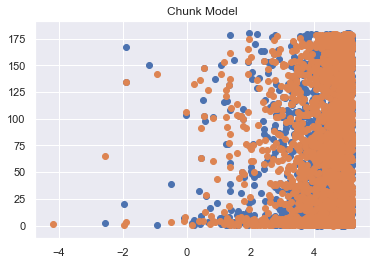

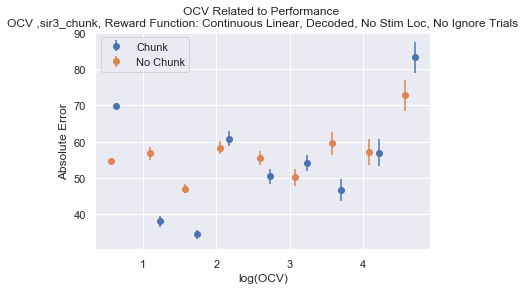

      AbsoluteError                                          TrialName  \
1709            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
1709 -2.551942     68.0  
excluded
      AbsoluteError                                          TrialName  \
382            20.4  Recall3_181.89767746946896_mnt1_145.9900147192...   
1060          134.9  Recall2_224.7360748453479_mnt1_256.43281187897...   
1059          166.9  Recall2_193.68492758357658_mnt1_256.4328118789...   

        logOCV  mod_lab  
382  -1.948807     13.0  
1060 -1.915360     41.0  
1059 -1.915360     41.0  
excluded
      AbsoluteError                                          TrialName  \
1320          150.3  Recall2_146.09286894556652_mnt1_359.9894663360...   

        logOCV  mod_lab  
1320 -1.177709     51.0  
excluded
      AbsoluteError                                          TrialName  \
1757            0.5  Recall2_217.58110902471998_mnt1_292.0465578503...   

        logOCV  mod_l

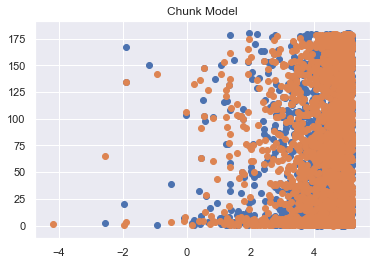

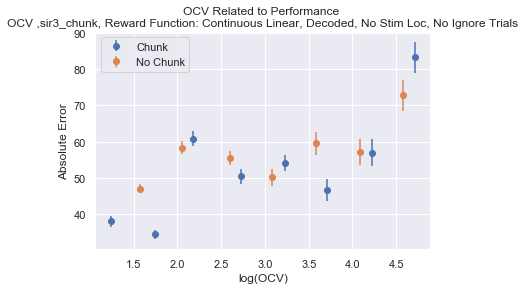

In [9]:
#original number of trials and models, sir3 
chunk = pd.read_csv('sir3_good_order')
nochunk = pd.read_csv('sir3_good_order_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"

# #need to run this part only once
# full_files = getfiles(base1)
# p = Precision()
# err = p.mult_models(full_files)
# #df_recall = p.dat.loc['True']
# df = p.dat
# df['ind'] = range(len(df))
# df_recall = df.loc['True']
# df_chunk = df

# full_files = getfiles(base2)
# p = Precision()
# err = p.mult_models(full_files)
# #df_recall = p.dat.loc['True']
# df = p.dat
# df['ind'] = range(len(df))
# nocdf_recall = df.loc['True']
# df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10, uniform = False,chunkdf_recall = chunk, nochunkdf_recall = nochunk, df_chunk = df_chunk, df_nochunk = df_nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 20, uniform = False,chunkdf_recall = chunk, nochunkdf_recall = nochunk,df_chunk = df_chunk, df_nochunk = df_nochunk)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:389: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
2102           1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040          94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            1.9  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:440: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
2102         124.50  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040           0.73  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            2.5  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710           88.6  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           18.1  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

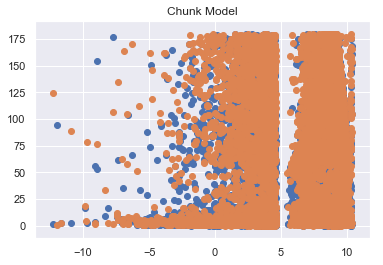

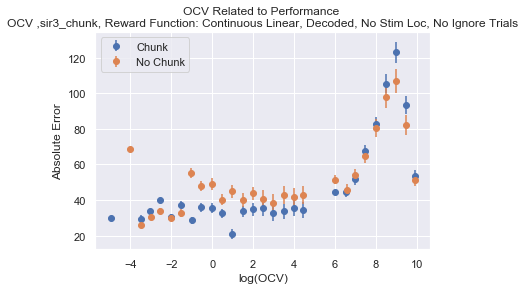

      AbsoluteError                                          TrialName  \
2102           1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040          94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            1.9  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

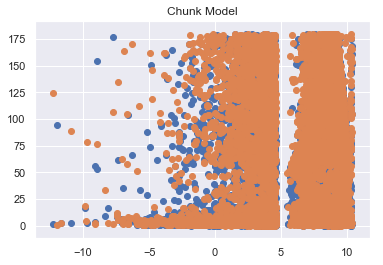

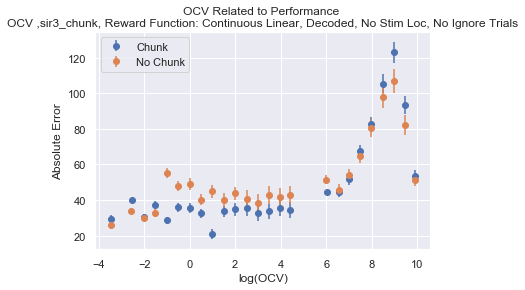

In [13]:
#chunk, 

base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
#need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 10, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk, df_nochunk = df_nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:393: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:444: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


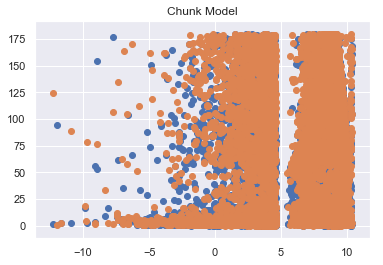

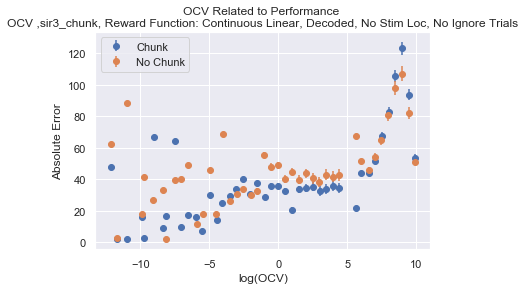

      AbsoluteError                                          TrialName  \
2102           1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040          94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            1.9  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

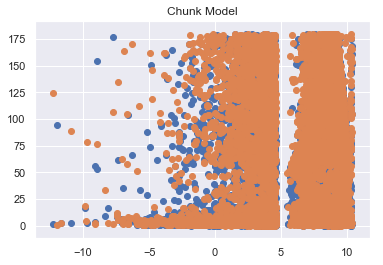

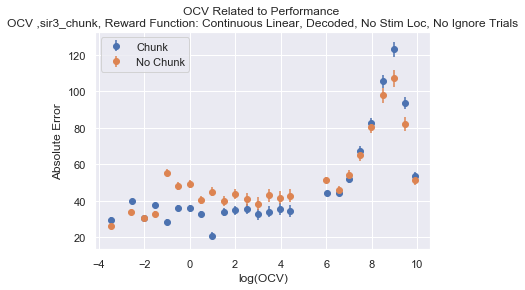

In [3]:
#chunk, 

base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
#need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 0, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk, df_nochunk = df_nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:389: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


       AbsoluteError                                          TrialName  \
2102            1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040           94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   
11550           1.90  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
2102  -5.442843     12.0  
8040  -5.316708     45.0  
11550 -5.142393     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
7710 -4.777132     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   
3418            2.5  Recall1_220.9988758352952_mnt1_-1_mnt2_-1_mnt3...   

        logOCV  mod_lab  
3086 -4.245532     17.0  
3418 -4.168235     19.0  
excluded
       AbsoluteError                                          

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:440: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


       AbsoluteError                                          TrialName  \
2102          124.50  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040            0.73  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   
11550           2.50  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
2102  -5.442843     12.0  
8040  -5.316708     45.0  
11550 -5.142393     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710           88.6  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
7710 -4.777132     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           18.1  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   
9966            4.1  Recall3_279.0742090678804_mnt1_-1_mnt2_-1_mnt3...   
3418           78.2  Recall1_220.9988758352952_mnt1_-1_mnt2_-1_mnt3...   

        logOCV  mod_lab  
3086 -4.245532     17.0  
9966 -4.182318     56.0

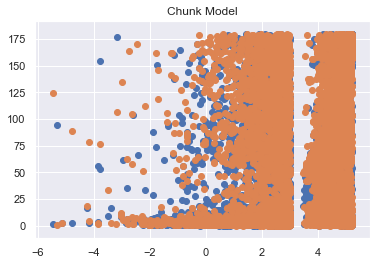

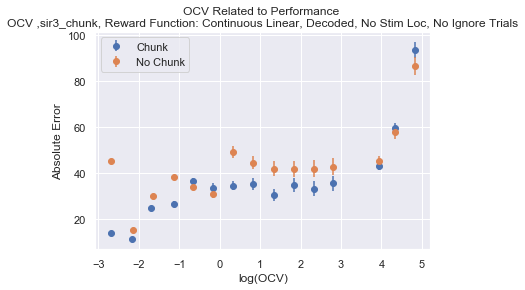

       AbsoluteError                                          TrialName  \
2102            1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040           94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   
11550           1.90  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
2102  -5.442843     12.0  
8040  -5.316708     45.0  
11550 -5.142393     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
7710 -4.777132     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   
3418            2.5  Recall1_220.9988758352952_mnt1_-1_mnt2_-1_mnt3...   

        logOCV  mod_lab  
3086 -4.245532     17.0  
3418 -4.168235     19.0  
excluded
       AbsoluteError                                          

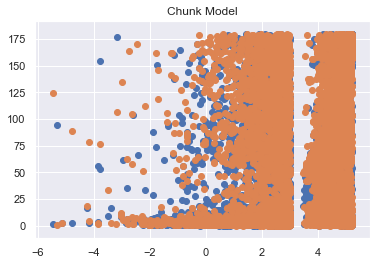

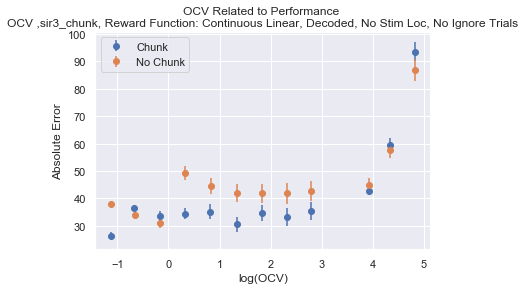

      AbsoluteError                                          TrialName  \
2102           1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040          94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            1.9  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

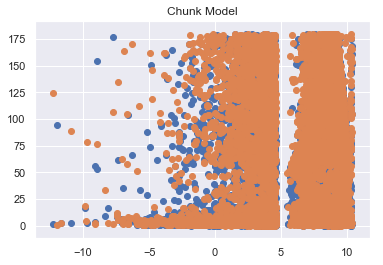

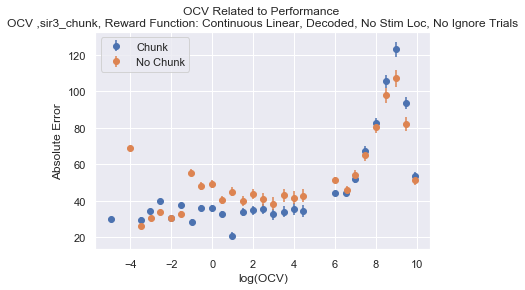

      AbsoluteError                                          TrialName  \
2102           1.30  Recall1_124.85591014287215_mnt1_-1_mnt2_-1_mnt...   
8040          94.58  Recall2_65.3644763171792_mnt1_-1_mnt2_-1_mnt3_...   

         logOCV  mod_lab  
2102 -12.271981     12.0  
8040 -12.019711     45.0  
excluded
       AbsoluteError                                          TrialName  \
11550            1.9  Recall1_163.36715388469864_mnt1_-1_mnt2_-1_mnt...   

          logOCV  mod_lab  
11550 -11.671079     66.0  
excluded
      AbsoluteError                                          TrialName  \
7710            2.1  Recall3_272.61625469610294_mnt1_-1_mnt2_-1_mnt...   

         logOCV  mod_lab  
7710 -10.940559     44.0  
excluded
      AbsoluteError                                          TrialName  \
3086           16.3  Recall3_236.82026818817928_mnt1_-1_mnt2_-1_mnt...   

        logOCV  mod_lab  
3086 -9.877359     17.0  
excluded
      AbsoluteError                              

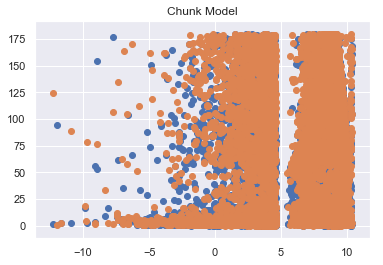

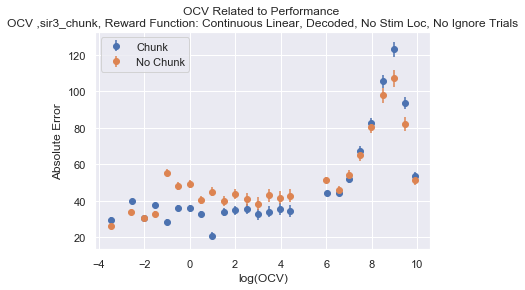

In [3]:
#chunk, 

base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
#need to run this part only once
full_files = getfiles(base1)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
df_recall = df.loc['True']
df_chunk = df

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
#df_recall = p.dat.loc['True']
df = p.dat
df['ind'] = range(len(df))
nocdf_recall = df.loc['True']
df_nochunk = df

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk, df_nochunk = df_nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 20, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk)

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 10, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall, df_chunk = df_chunk, df_nochunk = df_nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20, uniform = True,chunkdf_recall = df_recall, nochunkdf_recall = nocdf_recall,df_chunk = df_chunk, df_nochunk = df_nochunk)

In [ ]:
#average below and above the 0;
#wait the chunktrials above and below does not make sense.

      AbsoluteError                                          TrialName  \
2179          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   

        logOCV  mod_lab  
2179 -3.015479     43.0  
excluded
     AbsoluteError                                          TrialName  \
658         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

       logOCV  mod_lab  
658 -2.044319     13.0  
excluded
      AbsoluteError                                          TrialName  \
1851            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   
817             1.1  Recall1_329.00494611601073_mnt1_-1_mnt2_275.55...   
2478          109.7  Recall3_108.9488164292292_mnt1_63.845223913032...   
3730            1.8  Recall1_123.16515279930515_mnt1_-1_mnt2_1.6298...   

        logOCV  mod_lab  
1851 -1.807650     37.0  
817  -1.574479     16.0  
2478 -1.557029     49.0  
3730 -1.551937     76.0  
excluded
      AbsoluteError                                          TrialName  \


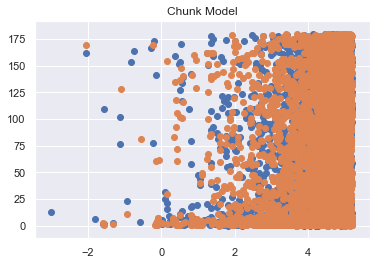

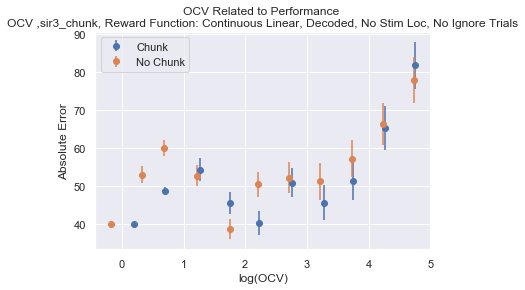

      AbsoluteError                                          TrialName  \
2179          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   

        logOCV  mod_lab  
2179 -3.015479     43.0  
excluded
     AbsoluteError                                          TrialName  \
658         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

       logOCV  mod_lab  
658 -2.044319     13.0  
excluded
      AbsoluteError                                          TrialName  \
1851            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   
817             1.1  Recall1_329.00494611601073_mnt1_-1_mnt2_275.55...   
2478          109.7  Recall3_108.9488164292292_mnt1_63.845223913032...   
3730            1.8  Recall1_123.16515279930515_mnt1_-1_mnt2_1.6298...   

        logOCV  mod_lab  
1851 -1.807650     37.0  
817  -1.574479     16.0  
2478 -1.557029     49.0  
3730 -1.551937     76.0  
excluded
      AbsoluteError                                          TrialName  \


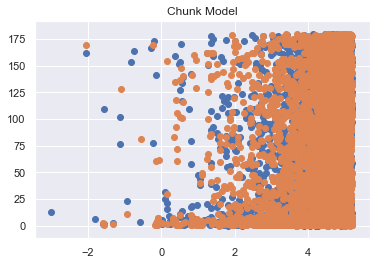

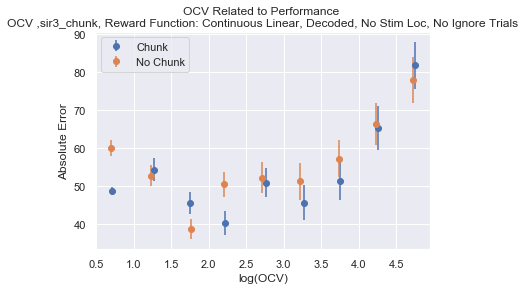

In [63]:
chunk = pd.read_csv('sir3_good_order_moretrials')
nochunk = pd.read_csv('sir3_good_order_moretrials_nochunk')
base ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"
full_files = getfiles(base)
p = Precision()
err = p.mult_models(full_files)
chunk = p.dat.loc['True']

full_files = getfiles(base2)
p = Precision()
err = p.mult_models(full_files)
nochunk = p.dat.loc['True']

chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 10, chunkdf_recall = chunk, nochunkdf_recall = nochunk, uniform = False)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'var',mintrial = 20,chunkdf_recall = chunk, nochunkdf_recall = nochunk, uniform = False)

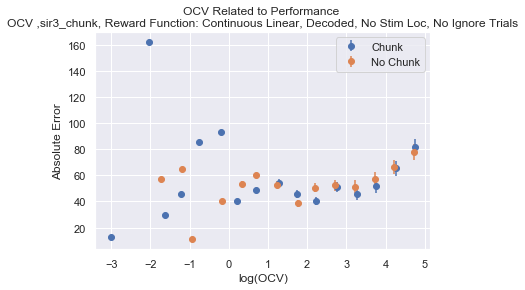

      AbsoluteError                                          TrialName  \
2179          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   

        logOCV  mod_lab  
2179 -3.015479     43.0  
excluded
     AbsoluteError                                          TrialName  \
658         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

       logOCV  mod_lab  
658 -2.044319     13.0  
excluded
      AbsoluteError                                          TrialName  \
1851            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   
817             1.1  Recall1_329.00494611601073_mnt1_-1_mnt2_275.55...   
2478          109.7  Recall3_108.9488164292292_mnt1_63.845223913032...   
3730            1.8  Recall1_123.16515279930515_mnt1_-1_mnt2_1.6298...   

        logOCV  mod_lab  
1851 -1.807650     37.0  
817  -1.574479     16.0  
2478 -1.557029     49.0  
3730 -1.551937     76.0  
excluded
      AbsoluteError                                          TrialName  \


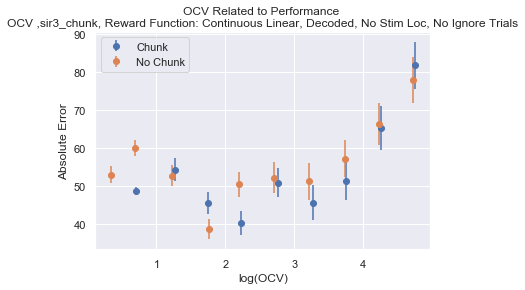

In [15]:
chunk = pd.read_csv('sir3_good_order_moretrials')
nochunk = pd.read_csv('sir3_good_order_moretrials_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall =chunk , nochunkdf_recall = nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 15, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

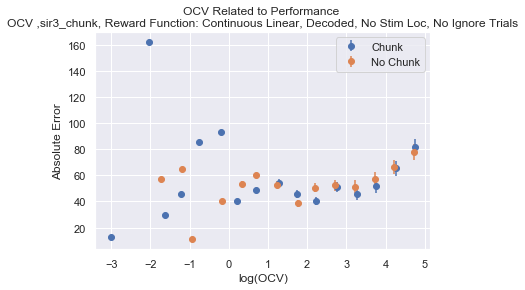

      AbsoluteError                                          TrialName  \
2179          12.48  Recall2_91.07530822286321_mnt1_128.22573158271...   

        logOCV  mod_lab  
2179 -3.015479     43.0  
excluded
     AbsoluteError                                          TrialName  \
658         162.25  Recall2_181.52408125184084_mnt1_18.52969533769...   

       logOCV  mod_lab  
658 -2.044319     13.0  
excluded
      AbsoluteError                                          TrialName  \
1851            6.3  Recall2_315.2206573494759_mnt1_97.365042024080...   
817             1.1  Recall1_329.00494611601073_mnt1_-1_mnt2_275.55...   
2478          109.7  Recall3_108.9488164292292_mnt1_63.845223913032...   
3730            1.8  Recall1_123.16515279930515_mnt1_-1_mnt2_1.6298...   

        logOCV  mod_lab  
1851 -1.807650     37.0  
817  -1.574479     16.0  
2478 -1.557029     49.0  
3730 -1.551937     76.0  
excluded
      AbsoluteError                                          TrialName  \


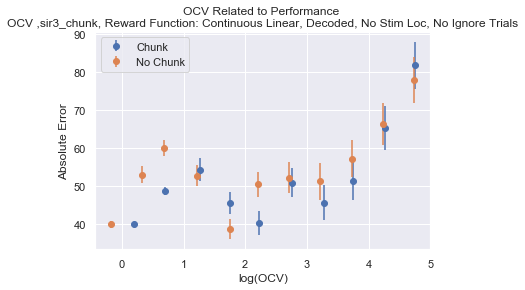

In [3]:
chunk = pd.read_csv('sir3_good_order_moretrials')
nochunk = pd.read_csv('sir3_good_order_moretrials_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretrials/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretrials/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall =chunk , nochunkdf_recall = nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

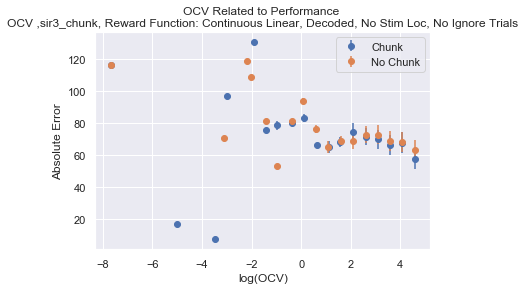

      AbsoluteError                                          TrialName  \
2193          116.0  Recall1_351.6374456358862_mnt1_-1_mnt2_239.014...   

        logOCV  mod_lab  
2193 -7.683788     17.0  
excluded
      AbsoluteError                                          TrialName  \
7221           16.7  Recall1_308.13731956862586_mnt1_-1_mnt2_328.70...   

        logOCV  mod_lab  
7221 -4.993935     57.0  
excluded
      AbsoluteError                                          TrialName  \
5272            7.3  Recall1_330.8755044416737_mnt1_-1_mnt2_192.010...   

        logOCV  mod_lab  
5272 -3.480112     42.0  
excluded
      AbsoluteError                                          TrialName  \
1637         140.82  Recall1_96.19965587690092_mnt1_-1_mnt2_236.729...   
2300           1.40  Recall2_198.53635893575344_mnt1_23.01011587409...   
7361         118.90  Recall2_354.21611616542816_mnt1_233.9447318514...   
8118         125.44  Recall3_69.19926224671349_mnt1_301.90468308237...   


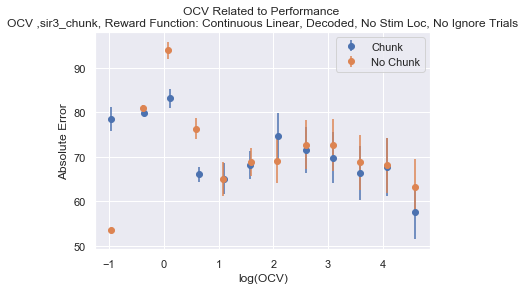

In [4]:
chunk = pd.read_csv('sir3_bad_order_moretrials')
nochunk = pd.read_csv('sir3_bad_order_moretrials_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretrials/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretrials/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall =chunk , nochunkdf_recall = nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

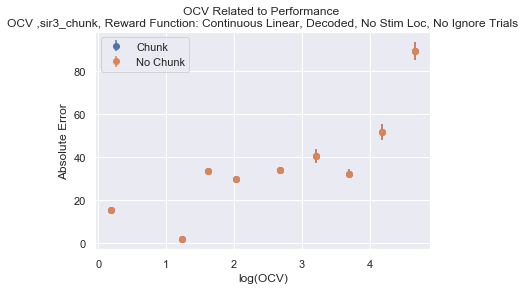

     AbsoluteError                                          TrialName  \
489          7.500  Recall1_134.1170220675028_mnt1_-1_mnt2_28.0082...   
360          5.400  Recall1_324.8852897782232_mnt1_-1_mnt2_41.9943...   
494         32.595  Recall1_29.310562847490335_mnt1_-1_mnt2_205.98...   

       logOCV  mod_lab  
489 -0.086003     63.0  
360  0.245751     48.0  
494  0.383110     64.0  
excluded
     AbsoluteError                                          TrialName  \
361           1.20  Recall2_302.8858614629403_mnt1_310.30031470691...   
408           2.70  Recall2_206.40653538914654_mnt1_14.31680696955...   
114           0.77  Recall2_91.64998934157131_mnt1_196.35807203956...   
420           2.78  Recall3_72.24360247307399_mnt1_340.43631629648...   
417           0.10  Recall2_170.3043587993588_mnt1_165.14715284234...   

       logOCV  mod_lab  
361  1.089765     48.0  
408  1.170633     54.0  
114  1.262719     12.0  
420  1.323947     57.0  
417  1.347507     55.0  
excluded


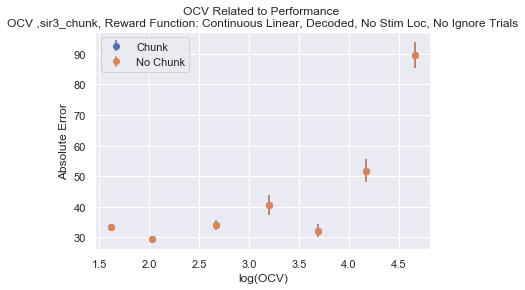

In [27]:
#need to re-run this in the morning
chunk = pd.read_csv('sir3_loc_OCI_good')
nochunk = pd.read_csv('sir3_loc_OCI_good_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall =chunk , nochunkdf_recall = nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

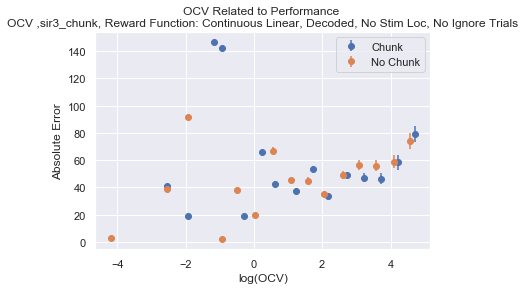

      AbsoluteError                                          TrialName  \
1709           41.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
1709 -2.551942     68.0  
excluded
      AbsoluteError                                          TrialName  \
382             0.2  Recall3_181.89767746946896_mnt1_145.9900147192...   
1060           19.4  Recall2_224.7360748453479_mnt1_256.43281187897...   
1059           56.6  Recall2_193.68492758357658_mnt1_256.4328118789...   

        logOCV  mod_lab  
382  -1.948807     13.0  
1060 -1.915360     41.0  
1059 -1.915360     41.0  
excluded
      AbsoluteError                                          TrialName  \
1320          146.9  Recall2_146.09286894556652_mnt1_359.9894663360...   

        logOCV  mod_lab  
1320 -1.177709     51.0  
excluded
      AbsoluteError                                          TrialName  \
1757          142.3  Recall2_217.58110902471998_mnt1_292.0465578503...   

        logOCV  mod_l

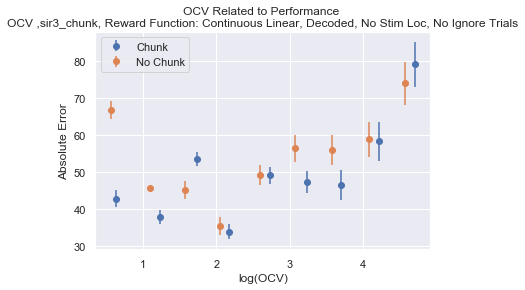

In [14]:
chunk = pd.read_csv('sir3_good_order_lrate06')
nochunk = pd.read_csv('sir3_good_order_lrate06_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall =chunk , nochunkdf_recall = nochunk)


chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

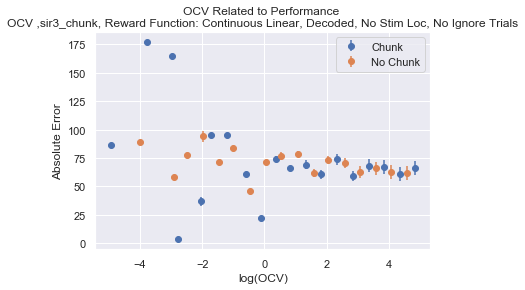

      AbsoluteError                                          TrialName  \
4230           86.4  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
4230 -4.937521     54.0  
excluded
      AbsoluteError                                          TrialName  \
1847          177.2  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
1847 -3.765899     23.0  
excluded
      AbsoluteError                                          TrialName  \
3557         164.98  Recall1_38.8950570836081_mnt1_-1_mnt2_231.5543...   

        logOCV  mod_lab  
3557 -2.965075     45.0  
excluded
      AbsoluteError                                          TrialName  \
4789            4.5  Recall2_249.3943532297853_mnt1_204.33457623416...   
2823            2.4  Recall3_186.89052588245033_mnt1_183.8020091109...   

        logOCV  mod_lab  
4789 -2.897386     62.0  
2823 -2.632767     36.0  
excluded
      AbsoluteError                                         

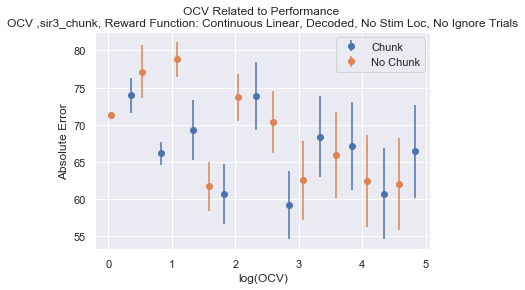

In [3]:
chunk = pd.read_csv('both_stripes_used')
nochunk = pd.read_csv('both_stripes_used_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

In [9]:
len(chunk)

1524

In [10]:
len(nochunk)

1480

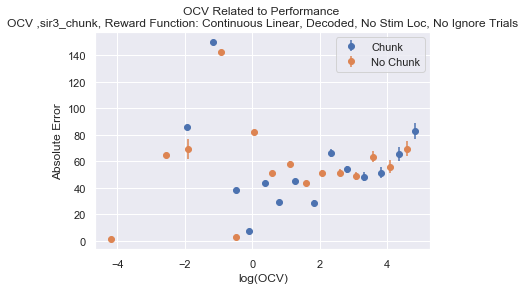

     AbsoluteError                                          TrialName  \
309           20.4  Recall3_181.89767746946896_mnt1_145.9900147192...   
794          166.9  Recall2_193.68492758357658_mnt1_256.4328118789...   
795          134.9  Recall2_224.7360748453479_mnt1_256.43281187897...   

       logOCV  mod_lab  
309 -1.948807     11.0  
794 -1.915360     34.0  
795 -1.915360     34.0  
excluded
      AbsoluteError                                          TrialName  \
1016          150.3  Recall2_146.09286894556652_mnt1_359.9894663360...   

        logOCV  mod_lab  
1016 -1.177709     44.0  
excluded
      AbsoluteError                                          TrialName  \
1367         38.507  Recall3_318.9384209166197_mnt1_11.761349515707...   

        logOCV  mod_lab  
1367 -0.494204     60.0  
excluded
      AbsoluteError                                          TrialName  \
1331            7.5  Recall1_134.1170220675028_mnt1_-1_mnt2_28.0082...   

        logOCV  mod_lab  
133

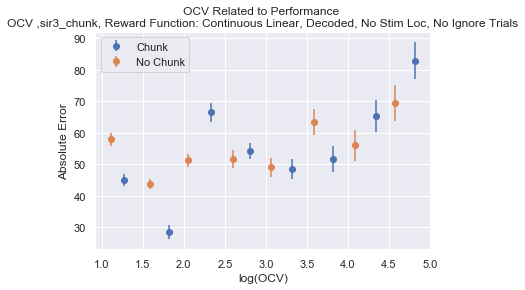

In [8]:
chunk = pd.read_csv('both_stripes_used_and_good_order')
nochunk = pd.read_csv('both_stripes_used_and_good_order_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

In [18]:
chunk = pd.read_csv('sir3_good_order')
nochunk = pd.read_csv('sir3_good_order_nochunk')

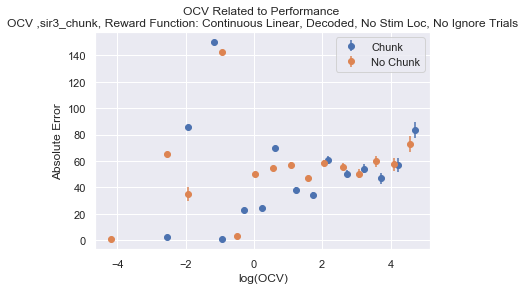

In [21]:
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

      AbsoluteError                                          TrialName  \
1709            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
1709 -2.551942     68.0  
excluded
      AbsoluteError                                          TrialName  \
382            20.4  Recall3_181.89767746946896_mnt1_145.9900147192...   
1060          134.9  Recall2_224.7360748453479_mnt1_256.43281187897...   
1059          166.9  Recall2_193.68492758357658_mnt1_256.4328118789...   

        logOCV  mod_lab  
382  -1.948807     13.0  
1060 -1.915360     41.0  
1059 -1.915360     41.0  
excluded
      AbsoluteError                                          TrialName  \
1320          150.3  Recall2_146.09286894556652_mnt1_359.9894663360...   

        logOCV  mod_lab  
1320 -1.177709     51.0  
excluded
      AbsoluteError                                          TrialName  \
1757            0.5  Recall2_217.58110902471998_mnt1_292.0465578503...   

        logOCV  mod_l

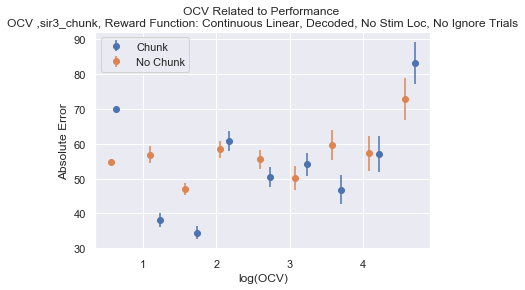

In [25]:
chunk = pd.read_csv('sir3_good_order')
nochunk = pd.read_csv('sir3_good_order_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

      AbsoluteError                                          TrialName  \
3835           86.4  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
3835 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
1730          177.2  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
1730 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
3282         164.98  Recall1_38.8950570836081_mnt1_-1_mnt2_231.5543...   

        logOCV  mod_lab  
3282 -2.965075     51.0  
excluded
      AbsoluteError                                          TrialName  \
4581            4.5  Recall2_249.3943532297853_mnt1_204.33457623416...   
2684            2.4  Recall3_186.89052588245033_mnt1_183.8020091109...   

        logOCV  mod_lab  
4581 -2.897386     71.0  
2684 -2.632767     42.0  
excluded
      AbsoluteError                                         

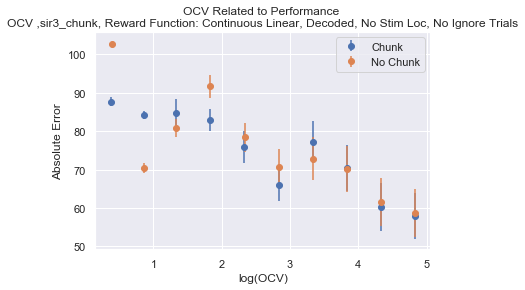

In [23]:
chunk = pd.read_csv('sir3_bad_order')
nochunk = pd.read_csv('sir3_bad_order_nochunk')
base1 = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 15, chunkdf_recall =chunk , nochunkdf_recall = nochunk)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


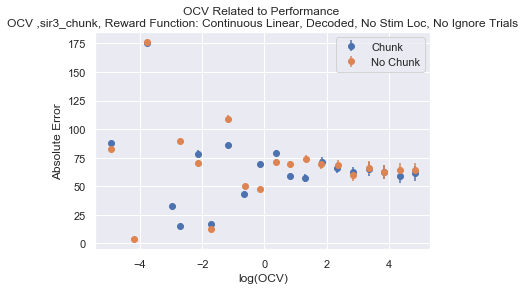

In [7]:
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate06/"
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate06/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348           87.4  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
2433          175.2  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
4608          32.78  Recall1_38.8950570836081_mnt1_-1_mnt2_231.5543...   

        logOCV  mod_lab  
4608 -2.965075     51.0  
excluded
      AbsoluteError                                          TrialName  \
6366            1.9  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760            1.9  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070           41.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348           82.3  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
6706          3.265  Recall3_4.711696178982755_mnt1_216.01348086003...   

        logOCV  mod_lab  
6706 -4.197085     75.0  
excluded
      AbsoluteError                                          TrialName  \
2433          176.5  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
6366           56.0  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760          172.7  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070           38.8  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

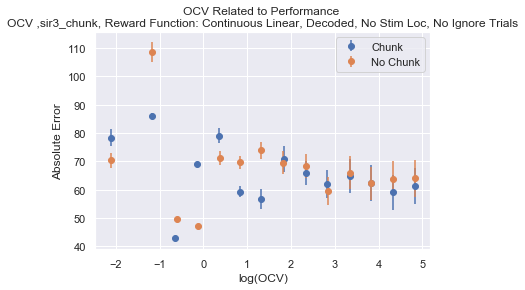

In [16]:
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate06/"
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate06/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 5)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348           87.4  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
2433          175.2  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
4608          32.78  Recall1_38.8950570836081_mnt1_-1_mnt2_231.5543...   

        logOCV  mod_lab  
4608 -2.965075     51.0  
excluded
      AbsoluteError                                          TrialName  \
6366            1.9  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760            1.9  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070           41.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348           82.3  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
6706          3.265  Recall3_4.711696178982755_mnt1_216.01348086003...   

        logOCV  mod_lab  
6706 -4.197085     75.0  
excluded
      AbsoluteError                                          TrialName  \
2433          176.5  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
6366           56.0  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760          172.7  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070           38.8  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

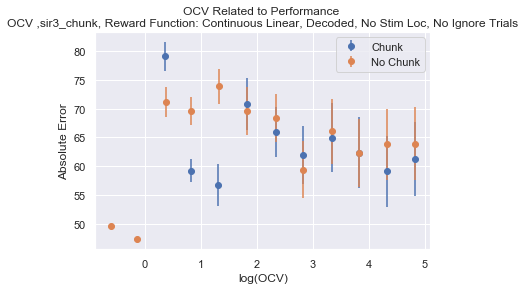

In [17]:
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate06/"
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate06/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 10)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


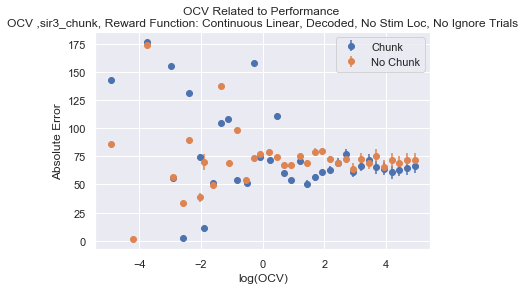

In [14]:
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip16/"
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip16/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 0)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348          143.1  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
2433          177.2  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
4608         155.98  Recall1_38.8950570836081_mnt1_-1_mnt2_231.5543...   

        logOCV  mod_lab  
4608 -2.965075     51.0  
excluded
      AbsoluteError                                          TrialName  \
6366           55.9  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760            2.4  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348           85.7  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
6706          1.041  Recall3_4.711696178982755_mnt1_216.01348086003...   

        logOCV  mod_lab  
6706 -4.197085     75.0  
excluded
      AbsoluteError                                          TrialName  \
2433          174.3  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
6366           56.9  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760            4.8  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070           63.0  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

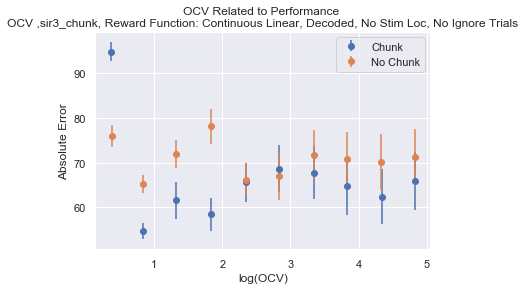

In [21]:
base2 ="Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip16/"
base1 ="Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip16/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff',mintrial = 15)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


got files


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:403: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


got df recall


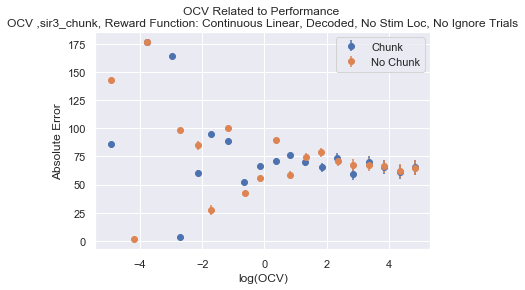

In [4]:

base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 0 )

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348           86.4  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
2433          177.2  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
4608         164.98  Recall1_38.8950570836081_mnt1_-1_mnt2_231.5543...   

        logOCV  mod_lab  
4608 -2.965075     51.0  
excluded
      AbsoluteError                                          TrialName  \
6366            4.5  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760            2.4  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348          143.1  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
6706          1.041  Recall3_4.711696178982755_mnt1_216.01348086003...   

        logOCV  mod_lab  
6706 -4.197085     75.0  
excluded
      AbsoluteError                                          TrialName  \
2433          177.3  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
6366           58.4  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760          172.7  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070           65.1  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

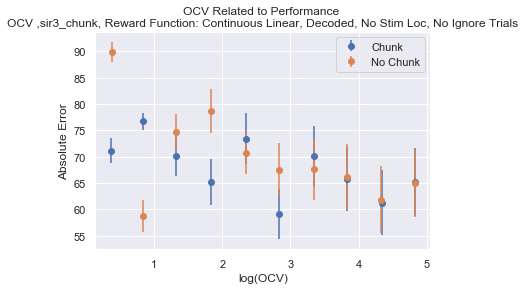

In [20]:

base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 15)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348           86.4  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
2433          177.2  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
4608         164.98  Recall1_38.8950570836081_mnt1_-1_mnt2_231.5543...   

        logOCV  mod_lab  
4608 -2.965075     51.0  
excluded
      AbsoluteError                                          TrialName  \
6366            4.5  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760            2.4  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348          143.1  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
6706          1.041  Recall3_4.711696178982755_mnt1_216.01348086003...   

        logOCV  mod_lab  
6706 -4.197085     75.0  
excluded
      AbsoluteError                                          TrialName  \
2433          177.3  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
6366           58.4  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760          172.7  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070           65.1  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

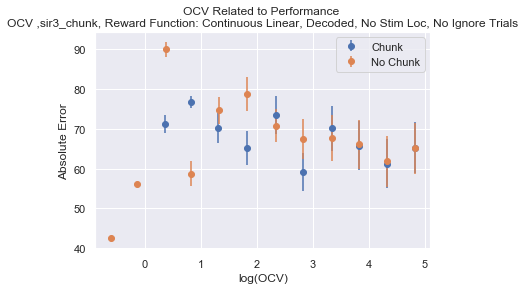

In [8]:

base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 10)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348           86.4  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
2433          177.2  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
4608         164.98  Recall1_38.8950570836081_mnt1_-1_mnt2_231.5543...   

        logOCV  mod_lab  
4608 -2.965075     51.0  
excluded
      AbsoluteError                                          TrialName  \
6366            4.5  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760            2.4  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070            2.4  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348          143.1  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
6706          1.041  Recall3_4.711696178982755_mnt1_216.01348086003...   

        logOCV  mod_lab  
6706 -4.197085     75.0  
excluded
      AbsoluteError                                          TrialName  \
2433          177.3  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
6366           58.4  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760          172.7  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070           65.1  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

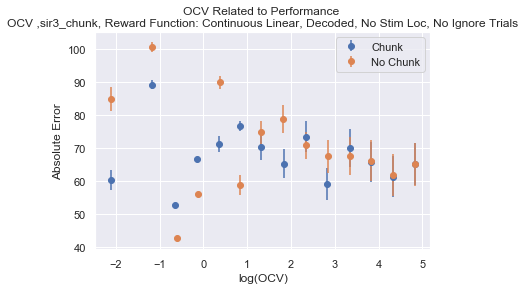

In [9]:

base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 5
                                                                                    )

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5348           82.3  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
2433          179.1  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
4608         164.18  Recall1_38.8950570836081_mnt1_-1_mnt2_231.5543...   

        logOCV  mod_lab  
4608 -2.965075     51.0  
excluded
      AbsoluteError                                          TrialName  \
6366            7.5  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760            5.1  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070            1.0  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2.632767     42

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:403: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


got df recall
      AbsoluteError                                          TrialName  \
5348           83.7  Recall1_216.63893429573696_mnt1_-1_mnt2_300.49...   

        logOCV  mod_lab  
5348 -4.937521     60.0  
excluded
      AbsoluteError                                          TrialName  \
6706        141.959  Recall3_4.711696178982755_mnt1_216.01348086003...   

        logOCV  mod_lab  
6706 -4.197085     75.0  
excluded
      AbsoluteError                                          TrialName  \
2433          176.2  Recall1_57.82610871368102_mnt1_-1_mnt2_232.839...   

        logOCV  mod_lab  
2433 -3.765899     27.0  
excluded
      AbsoluteError                                          TrialName  \
6366            2.3  Recall2_249.3943532297853_mnt1_204.33457623416...   
3760            6.3  Recall3_186.89052588245033_mnt1_183.8020091109...   
6070            1.6  Recall2_252.83381010565813_mnt1_190.5499056772...   

        logOCV  mod_lab  
6366 -2.897386     71.0  
3760 -2

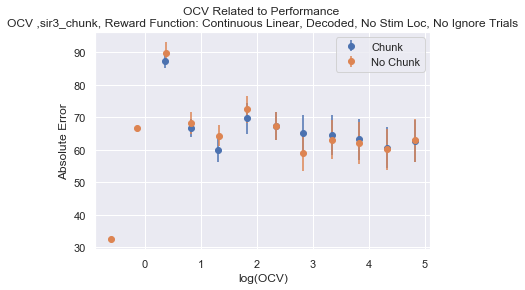

In [5]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip10/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip10/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 10)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
4667         12.285  Recall2_21.40622248217925_mnt1_335.06473340449...   

        logOCV  mod_lab  
4667 -4.324558     53.0  
excluded
     AbsoluteError                                          TrialName  \
639           12.6  Recall3_106.90323122631023_mnt1_148.4091057535...   

       logOCV  mod_lab  
639 -3.473754      7.0  
excluded
     AbsoluteError                                          TrialName  \
916            7.8  Recall2_177.80070465490377_mnt1_171.0625445151...   
917            0.5  Recall2_344.52799062983723_mnt1_171.0625445151...   
918            1.0  Recall2_106.61073799839151_mnt1_171.0625445151...   

       logOCV  mod_lab  
916 -3.226265     10.0  
917 -3.226265     10.0  
918 -3.226265     10.0  
excluded
      AbsoluteError                                          TrialName  \
4423           56.9  Recall3_332.5786994860772_mnt1_298.34487511185...   

        logOCV  mod_lab  
4423 -2

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
4276            2.5  Recall2_342.33041631058165_mnt1_240.7778969515...   

        logOCV  mod_lab  
4276 -4.394615     48.0  
excluded
      AbsoluteError                                          TrialName  \
3012          80.65  Recall1_81.49805233970518_mnt1_-1_mnt2_248.141...   
2154         139.90  Recall3_139.2550446219299_mnt1_132.63330057989...   

        logOCV  mod_lab  
3012 -2.877457     34.0  
2154 -2.782292     24.0  
excluded
      AbsoluteError                                          TrialName  \
5736           4.70  Recall2_227.5515721531353_mnt1_271.73717600201...   
1229          60.62  Recall1_58.90875358097052_mnt1_-1_mnt2_28.2588...   
5029          67.80  Recall1_291.7802574703424_mnt1_-1_mnt2_291.693...   

        logOCV  mod_lab  
5736 -1.956591     65.0  
1229 -1.922448     14.0  
5029 -1.921156     57.0  
excluded


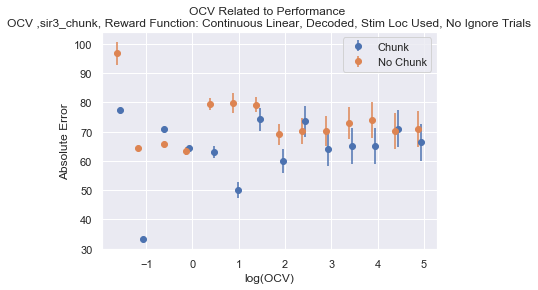

In [14]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo125/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo125/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 5)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
4667         12.285  Recall2_21.40622248217925_mnt1_335.06473340449...   

        logOCV  mod_lab  
4667 -4.324558     53.0  
excluded
     AbsoluteError                                          TrialName  \
639           12.6  Recall3_106.90323122631023_mnt1_148.4091057535...   

       logOCV  mod_lab  
639 -3.473754      7.0  
excluded
     AbsoluteError                                          TrialName  \
916            7.8  Recall2_177.80070465490377_mnt1_171.0625445151...   
917            0.5  Recall2_344.52799062983723_mnt1_171.0625445151...   
918            1.0  Recall2_106.61073799839151_mnt1_171.0625445151...   

       logOCV  mod_lab  
916 -3.226265     10.0  
917 -3.226265     10.0  
918 -3.226265     10.0  
excluded
      AbsoluteError                                          TrialName  \
4423           56.9  Recall3_332.5786994860772_mnt1_298.34487511185...   

        logOCV  mod_lab  
4423 -2

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
4276            2.5  Recall2_342.33041631058165_mnt1_240.7778969515...   

        logOCV  mod_lab  
4276 -4.394615     48.0  
excluded
      AbsoluteError                                          TrialName  \
3012          80.65  Recall1_81.49805233970518_mnt1_-1_mnt2_248.141...   
2154         139.90  Recall3_139.2550446219299_mnt1_132.63330057989...   

        logOCV  mod_lab  
3012 -2.877457     34.0  
2154 -2.782292     24.0  
excluded
      AbsoluteError                                          TrialName  \
5736           4.70  Recall2_227.5515721531353_mnt1_271.73717600201...   
1229          60.62  Recall1_58.90875358097052_mnt1_-1_mnt2_28.2588...   
5029          67.80  Recall1_291.7802574703424_mnt1_-1_mnt2_291.693...   

        logOCV  mod_lab  
5736 -1.956591     65.0  
1229 -1.922448     14.0  
5029 -1.921156     57.0  
excluded
      AbsoluteError                                          TrialName

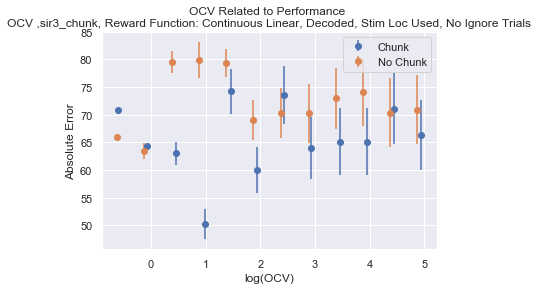

In [15]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo125/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo125/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 10)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
234            0.70  Recall2_142.3458942865574_mnt1_274.66841456788...   
6176          94.37  Recall3_94.30538086192293_mnt1_182.73298149539...   
1044           5.20  Recall2_351.3442729718195_mnt1_58.512160904883...   
1045           2.70  Recall2_161.60499087557355_mnt1_58.51216090488...   

        logOCV  mod_lab  
234  -3.218835      2.0  
6176 -3.059575     71.0  
1044 -2.961938     11.0  
1045 -2.961938     11.0  
excluded
      AbsoluteError                                          TrialName  \
3412           95.8  Recall2_248.76081356447492_mnt1_213.1250213275...   

        logOCV  mod_lab  
3412 -2.472147     39.0  
excluded
      AbsoluteError                                          TrialName  \
5928            0.7  Recall1_347.38139719953466_mnt1_-1_mnt2_164.41...   

        logOCV  mod_lab  
5928 -1.944062     68.0  
excluded


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5409          161.4  Recall1_198.45862342029884_mnt1_-1_mnt2_200.90...   

        logOCV  mod_lab  
5409 -4.218144     62.0  
excluded
     AbsoluteError                                          TrialName  \
264          142.3  Recall2_142.3458942865574_mnt1_274.66841456788...   

       logOCV  mod_lab  
264 -3.218835      2.0  
excluded
      AbsoluteError                                          TrialName  \
3579          123.2  Recall2_285.4372309665292_mnt1_160.92959493959...   
1037            0.1  Recall2_351.3442729718195_mnt1_58.512160904883...   
1038            3.1  Recall2_161.60499087557355_mnt1_58.51216090488...   

        logOCV  mod_lab  
3579 -3.179770     41.0  
1037 -2.961938     11.0  
1038 -2.961938     11.0  
excluded
      AbsoluteError                                          TrialName  \
5221           44.7  Recall3_310.89221609226485_mnt1_253.4739480484...   
5223           42.6  Recal

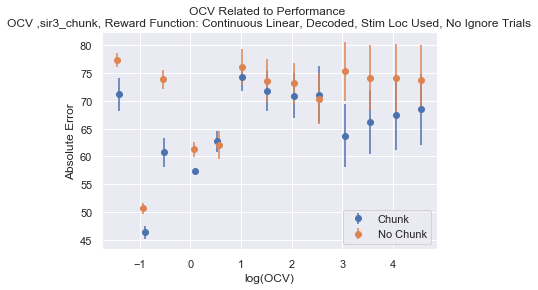

In [18]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 5)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
234            0.70  Recall2_142.3458942865574_mnt1_274.66841456788...   
6176          94.37  Recall3_94.30538086192293_mnt1_182.73298149539...   
1044           5.20  Recall2_351.3442729718195_mnt1_58.512160904883...   
1045           2.70  Recall2_161.60499087557355_mnt1_58.51216090488...   

        logOCV  mod_lab  
234  -3.218835      2.0  
6176 -3.059575     71.0  
1044 -2.961938     11.0  
1045 -2.961938     11.0  
excluded
      AbsoluteError                                          TrialName  \
3412           95.8  Recall2_248.76081356447492_mnt1_213.1250213275...   

        logOCV  mod_lab  
3412 -2.472147     39.0  
excluded
      AbsoluteError                                          TrialName  \
5928            0.7  Recall1_347.38139719953466_mnt1_-1_mnt2_164.41...   

        logOCV  mod_lab  
5928 -1.944062     68.0  
excluded
      AbsoluteError                                          TrialName

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5409          161.4  Recall1_198.45862342029884_mnt1_-1_mnt2_200.90...   

        logOCV  mod_lab  
5409 -4.218144     62.0  
excluded
     AbsoluteError                                          TrialName  \
264          142.3  Recall2_142.3458942865574_mnt1_274.66841456788...   

       logOCV  mod_lab  
264 -3.218835      2.0  
excluded
      AbsoluteError                                          TrialName  \
3579          123.2  Recall2_285.4372309665292_mnt1_160.92959493959...   
1037            0.1  Recall2_351.3442729718195_mnt1_58.512160904883...   
1038            3.1  Recall2_161.60499087557355_mnt1_58.51216090488...   

        logOCV  mod_lab  
3579 -3.179770     41.0  
1037 -2.961938     11.0  
1038 -2.961938     11.0  
excluded
      AbsoluteError                                          TrialName  \
5221           44.7  Recall3_310.89221609226485_mnt1_253.4739480484...   
5223           42.6  Recal

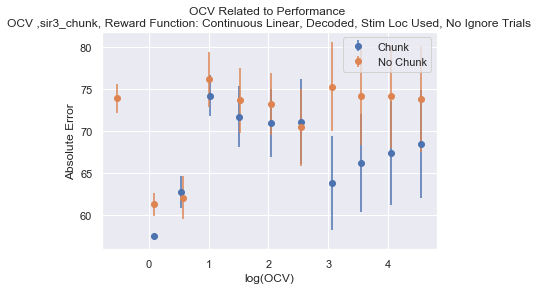

In [19]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 10)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
1441         11.631  Recall1_355.5874688226238_mnt1_-1_mnt2_37.3415...   

        logOCV  mod_lab  
1441 -4.496766     16.0  
excluded
     AbsoluteError                                          TrialName  \
197            0.9  Recall2_142.3458942865574_mnt1_274.66841456788...   

       logOCV  mod_lab  
197 -3.218835      2.0  
excluded
      AbsoluteError                                          TrialName  \
1021            0.7  Recall2_161.60499087557355_mnt1_58.51216090488...   
1020            2.1  Recall2_351.3442729718195_mnt1_58.512160904883...   

        logOCV  mod_lab  
1021 -2.961938     11.0  
1020 -2.961938     11.0  
excluded
      AbsoluteError                                          TrialName  \
3596           15.3  Recall2_312.6269950141382_mnt1_359.87922135602...   
344           113.9  Recall1_235.0498075818096_mnt1_-1_mnt2_134.607...   

        logOCV  mod_lab  
3596 -2.423128     40.0  

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
1471          38.48  Recall1_355.5874688226238_mnt1_-1_mnt2_37.3415...   

        logOCV  mod_lab  
1471 -4.496766     16.0  
excluded
     AbsoluteError                                          TrialName  \
218          134.4  Recall2_142.3458942865574_mnt1_274.66841456788...   

       logOCV  mod_lab  
218 -3.218835      2.0  
excluded
      AbsoluteError                                          TrialName  \
1026            7.4  Recall2_351.3442729718195_mnt1_58.512160904883...   
1027          161.5  Recall2_161.60499087557355_mnt1_58.51216090488...   
4814          119.6  Recall2_132.66943847792808_mnt1_247.7756435607...   

        logOCV  mod_lab  
1026 -2.961938     11.0  
1027 -2.961938     11.0  
4814 -2.573600     54.0  
excluded
      AbsoluteError                                          TrialName  \
3390           47.1  Recall2_248.76081356447492_mnt1_213.1250213275...   

        logOCV  mod_lab  

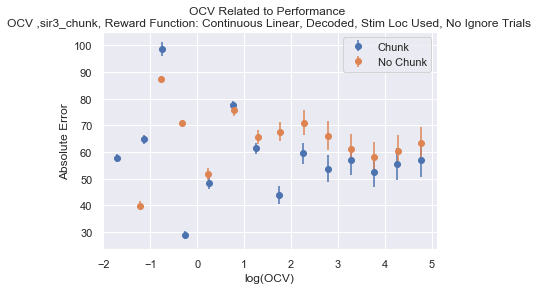

In [10]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoHidden/NoIgnore/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoHidden/NoIgnore/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 5)

> c:\users\aneri\go\src\leabra\examples\sir_proj\analysis\decodedoutputdefs.py(397)mult_models()
-> _,diffrecall = self.get_diffs(dat, nonresponse = nonresponse)


(Pdb)  c


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
1441         11.631  Recall1_355.5874688226238_mnt1_-1_mnt2_37.3415...   

        logOCV  mod_lab  
1441 -4.496766     16.0  
excluded
     AbsoluteError                                          TrialName  \
197            0.9  Recall2_142.3458942865574_mnt1_274.66841456788...   

       logOCV  mod_lab  
197 -3.218835      2.0  
excluded
      AbsoluteError                                          TrialName  \
1021            0.7  Recall2_161.60499087557355_mnt1_58.51216090488...   
1020            2.1  Recall2_351.3442729718195_mnt1_58.512160904883...   

        logOCV  mod_lab  
1021 -2.961938     11.0  
1020 -2.961938     11.0  
excluded
      AbsoluteError                                          TrialName  \
3596           15.3  Recall2_312.6269950141382_mnt1_359.87922135602...   
344           113.9  Recall1_235.0498075818096_mnt1_-1_mnt2_134.607...   

        logOCV  mod_lab  
3596 -2.423128     40.0  

(Pdb)  c


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:403: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


got df recall
      AbsoluteError                                          TrialName  \
1471          38.48  Recall1_355.5874688226238_mnt1_-1_mnt2_37.3415...   

        logOCV  mod_lab  
1471 -4.496766     16.0  
excluded
     AbsoluteError                                          TrialName  \
218          134.4  Recall2_142.3458942865574_mnt1_274.66841456788...   

       logOCV  mod_lab  
218 -3.218835      2.0  
excluded
      AbsoluteError                                          TrialName  \
1026            7.4  Recall2_351.3442729718195_mnt1_58.512160904883...   
1027          161.5  Recall2_161.60499087557355_mnt1_58.51216090488...   
4814          119.6  Recall2_132.66943847792808_mnt1_247.7756435607...   

        logOCV  mod_lab  
1026 -2.961938     11.0  
1027 -2.961938     11.0  
4814 -2.573600     54.0  
excluded
      AbsoluteError                                          TrialName  \
3390           47.1  Recall2_248.76081356447492_mnt1_213.1250213275...   

        log

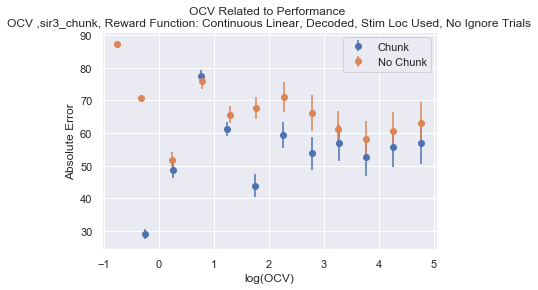

In [10]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoHidden/NoIgnore/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoHidden/NoIgnore/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 10)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
1441         11.631  Recall1_355.5874688226238_mnt1_-1_mnt2_37.3415...   

        logOCV  mod_lab  
1441 -4.496766     16.0  
excluded
     AbsoluteError                                          TrialName  \
197            0.9  Recall2_142.3458942865574_mnt1_274.66841456788...   

       logOCV  mod_lab  
197 -3.218835      2.0  
excluded
      AbsoluteError                                          TrialName  \
1021            0.7  Recall2_161.60499087557355_mnt1_58.51216090488...   
1020            2.1  Recall2_351.3442729718195_mnt1_58.512160904883...   

        logOCV  mod_lab  
1021 -2.961938     11.0  
1020 -2.961938     11.0  
excluded
      AbsoluteError                                          TrialName  \
3596           15.3  Recall2_312.6269950141382_mnt1_359.87922135602...   
344           113.9  Recall1_235.0498075818096_mnt1_-1_mnt2_134.607...   

        logOCV  mod_lab  
3596 -2.423128     40.0  

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
1471          38.48  Recall1_355.5874688226238_mnt1_-1_mnt2_37.3415...   

        logOCV  mod_lab  
1471 -4.496766     16.0  
excluded
     AbsoluteError                                          TrialName  \
218          134.4  Recall2_142.3458942865574_mnt1_274.66841456788...   

       logOCV  mod_lab  
218 -3.218835      2.0  
excluded
      AbsoluteError                                          TrialName  \
1026            7.4  Recall2_351.3442729718195_mnt1_58.512160904883...   
1027          161.5  Recall2_161.60499087557355_mnt1_58.51216090488...   
4814          119.6  Recall2_132.66943847792808_mnt1_247.7756435607...   

        logOCV  mod_lab  
1026 -2.961938     11.0  
1027 -2.961938     11.0  
4814 -2.573600     54.0  
excluded
      AbsoluteError                                          TrialName  \
3390           47.1  Recall2_248.76081356447492_mnt1_213.1250213275...   

        logOCV  mod_lab  

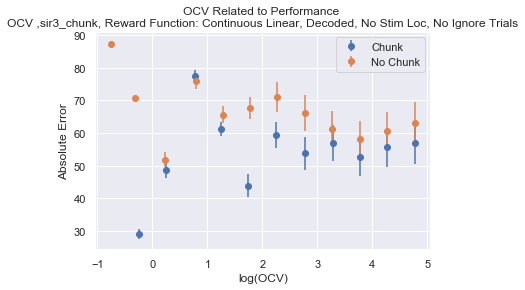

In [4]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 10)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


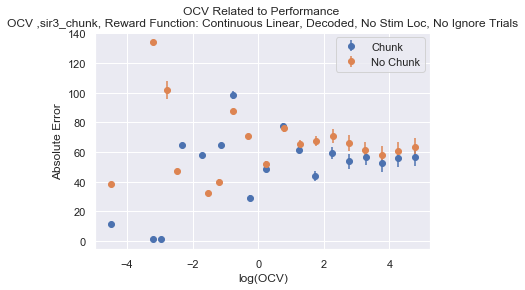

ValueError: too many values to unpack (expected 4)

In [3]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
chunkOCV, chunkOdf, nochunkOCV, nochunkOdf = plot_ocv_two(base1,base2, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:394: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


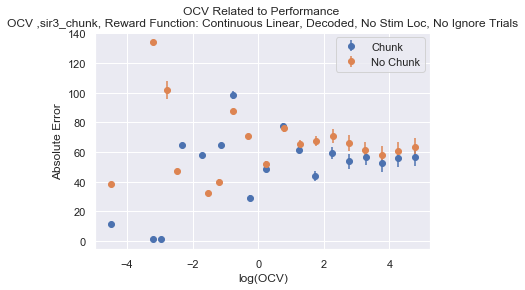

In [74]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
chunkOCV, chunkOdf, nochunkOCV, nochunkOdf = plot_ocv_two(base1,base2, var = 'diff')

In [165]:
chunk_file = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"

full_files = getfiles(chunk_file)
p = Precision()
#if len(bad)>0

err = p.mult_models(full_files)
df = p.dat
mod_labs = model_labels(np.array(df['|Trial']))
df['mod_lab'] = mod_labs

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
5936        156.357  Recall2_10.164593484055718_mnt1_162.9766970650...   
3008         78.520  Recall3_78.99488334482642_mnt1_26.152030996497...   

        logOCV  mod_lab  
5936 -4.072152     68.0  
3008 -3.906743     35.0  
excluded
      AbsoluteError                                          TrialName  \
2485          89.58  Recall1_88.67609959849044_mnt1_-1_mnt2_168.524...   
1052          30.80  Recall1_175.3465688544578_mnt1_-1_mnt2_149.604...   
97            10.60  Recall3_141.10566798992915_mnt1_153.4554251535...   

        logOCV  mod_lab  
2485 -3.474096     29.0  
1052 -3.356063     11.0  
97   -3.152592      1.0  
excluded
      AbsoluteError                                          TrialName  \
1227         103.70  Recall3_245.6258267052864_mnt1_285.48053779146...   
1226         149.90  Recall3_210.44452991982502_mnt1_285.4805377914...   
6818          23.12  Recall1_60.63592244357434_mnt1_-1_mnt

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError                                          TrialName  \
6066          4.443  Recall2_10.164593484055718_mnt1_162.9766970650...   
6754          0.000  Recall3_197.40822508475577_mnt1_39.60909194142...   
3140          1.540  Recall3_78.99488334482642_mnt1_26.152030996497...   

        logOCV  mod_lab  
6066 -4.072152     68.0  
6754 -3.971906     76.0  
3140 -3.906743     35.0  
excluded
      AbsoluteError                                          TrialName  \
1011           29.8  Recall1_175.3465688544578_mnt1_-1_mnt2_149.604...   

        logOCV  mod_lab  
1011 -3.356063     11.0  
excluded
      AbsoluteError                                          TrialName  \
2351          19.60  Recall2_318.35998792097587_mnt1_301.7648928140...   
7011          24.25  Recall1_60.63592244357434_mnt1_-1_mnt2_89.6890...   

        logOCV  mod_lab  
2351 -2.647513     26.0  
7011 -2.639270     78.0  
excluded
      AbsoluteError                                          TrialName

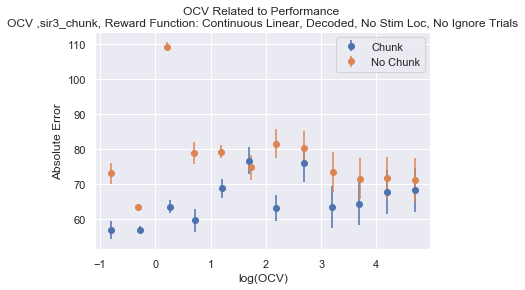

In [142]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chunkOCV, chunkOdf, chunkrecall, nochunkOCV, nochunkOdf, nochunkrecall = plot_ocv_two(base1,base2, var = 'diff', mintrial = 10)

In [174]:
num = 3967
trialint = chunkOdf.loc[num]['TrialName']
print(trialint)
print(chunkrecall[chunkrecall['$TrialName']==trialint]['#OutDecode'])
df[df['$TrialName']==trialint]

Recall1_74.46285674505168_mnt1_-1_mnt2_219.68365828817716_mnt3_219.37307075592855_rew_0
True    0.0
Name: #OutDecode, dtype: float64


,|Run,|Epoch,|Trial,$TrialName,#Err,#TrlDecodedDiff,#SSE,#AvgSSE,#CosDiff,#DA,...,#stripe,#stripe,#ChunkDecode,#OutDecode,#OutTarget,#InDecode,$Lesion,#LesionProp,$LesionApplied,mod_lab
True,0,-1,557,Recall1_74.46285674505168_mnt1_-1_mnt2_219.683...,1,74.66,3.213,0.1606,-0.3607,-0.3432,...,223.4,0.0,0.0,0.0,74.66,0.0,StimLoc,0,no,46


In [175]:
df[(df['|Trial']>552) & (df['|Trial']<558) & (df['mod_lab'] == 46)]

,|Run,|Epoch,|Trial,$TrialName,#Err,#TrlDecodedDiff,#SSE,#AvgSSE,#CosDiff,#DA,...,#stripe,#stripe,#ChunkDecode,#OutDecode,#OutTarget,#InDecode,$Lesion,#LesionProp,$LesionApplied,mod_lab
True,0,-1,553,Recall2_77.19852519524197_mnt1_-1_mnt2_-1_mnt3...,1,76.9900,3.213,0.1606,0.8325,-0.1763,...,0.0,0.0,0.00,0.00,76.99,0.00,StimLoc,0,no,46
False,0,-1,554,Store1_74.46285674505168_mnt1_74.4628567450516...,0,1.3500,0.000,0.0000,0.9688,0.0000,...,0.0,0.0,70.81,76.01,74.66,74.65,StimLoc,0,no,46
False,0,-1,555,Store2_219.68365828817716_mnt1_74.462856745051...,0,0.5289,0.000,0.0000,0.9688,0.0000,...,0.0,218.3,218.50,218.70,219.30,219.20,StimLoc,0,no,46
False,0,-1,556,Store3_219.37307075592855_mnt1_74.462856745051...,0,1.1130,0.000,0.0000,0.9583,0.0000,...,223.4,218.3,219.20,217.90,219.00,219.00,StimLoc,0,no,46
True,0,-1,557,Recall1_74.46285674505168_mnt1_-1_mnt2_219.683...,1,74.6600,3.213,0.1606,-0.3607,-0.3432,...,223.4,0.0,0.00,0.00,74.66,0.00,StimLoc,0,no,46


In [151]:
chunkOdf.loc[5454]['TrialName']

'Recall1_167.90838396591158_mnt1_-1_mnt2_147.5706819656793_mnt3_147.79972846377876_rew_0'

In [149]:
chunkOdf[chunkOdf['AbsoluteError'] == 168.30]

,logOCV,AbsoluteError,mod_lab,TrialName
5454,-1.473830,168.3,63,Recall1_167.90838396591158_mnt1_-1_mnt2_147.57...
2783,4.646778,168.3,33,Recall3_163.81405672319846_mnt1_323.0885010880...


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


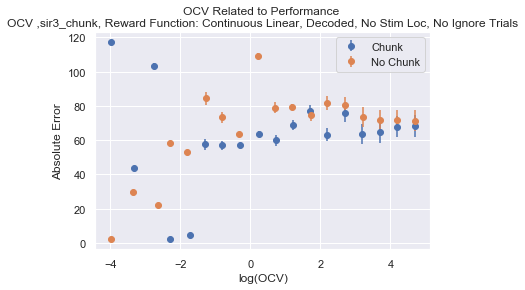

ValueError: too many values to unpack (expected 4)

In [177]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chunkOCV, chunkOdf, nochunkOCV, nochunkOdf = plot_ocv_two(base1,base2, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError    logOCV  mod_lab
5936        156.357 -4.072152     68.0
3008         78.520 -3.906743     35.0
excluded
      AbsoluteError    logOCV  mod_lab
2485          89.58 -3.474096     29.0
1052          30.80 -3.356063     11.0
97            10.60 -3.152592      1.0
excluded
      AbsoluteError    logOCV  mod_lab
1227         103.70 -3.048000     13.0
1226         149.90 -3.048000     13.0
6818          23.12 -2.639270     78.0
5288         159.90 -2.591021     61.0
excluded
      AbsoluteError    logOCV  mod_lab
1959           0.01 -2.344297     22.0
4083           1.60 -2.297682     48.0
6791           5.70 -2.215805     78.0
excluded
      AbsoluteError    logOCV  mod_lab
5327           4.66 -1.718934     62.0
excluded


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:394: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


      AbsoluteError    logOCV  mod_lab
6066          4.443 -4.072152     68.0
6754          0.000 -3.971906     76.0
3140          1.540 -3.906743     35.0
excluded
      AbsoluteError    logOCV  mod_lab
1011           29.8 -3.356063     11.0
excluded
      AbsoluteError    logOCV  mod_lab
2351          19.60 -2.647513     26.0
7011          24.25 -2.639270     78.0
excluded
      AbsoluteError    logOCV  mod_lab
2030         111.78 -2.344297     22.0
4221          58.50 -2.297682     48.0
6984           4.50 -2.215805     78.0
excluded
      AbsoluteError    logOCV  mod_lab
1185          62.90 -1.890565     13.0
5449          42.67 -1.718934     62.0
excluded


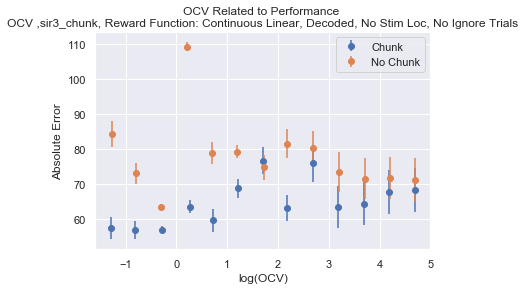

In [76]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chunkOCV, chunkOdf, nochunkOCV, nochunkOdf = plot_ocv_two(base1,base2, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:394: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


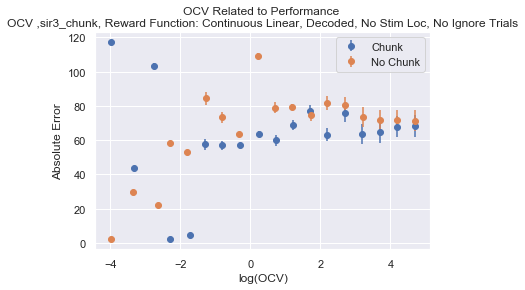

In [71]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chunkOCV, chunkOdf, nochunkOCV, nochunkOdf = plot_ocv_two(base1,base2, var = 'diff')

In [ ]:
why are some data points included in two?
also what doesit mean for log ocv to be negative

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:361: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:367: RuntimeWarning: invalid value encountered in log
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:379: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:384: RuntimeWarning: invalid value encountered in log


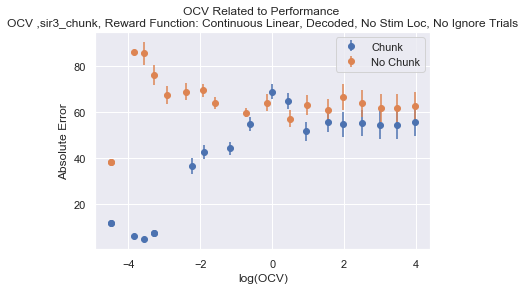

In [6]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
plot_ocv_two(base1,base2, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:359: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:377: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


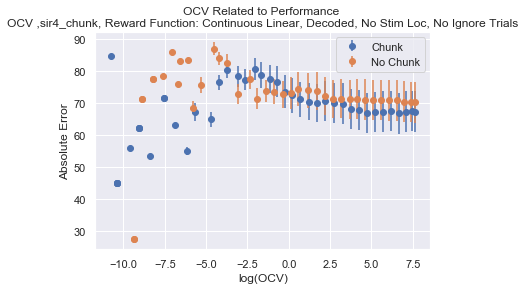

In [22]:
base2 = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
plot_ocv_two(base1,base2, var = 'var')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:272: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:274: RuntimeWarning: invalid value encountered in log
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:285: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:287: RuntimeWarning: invalid value encountered in log


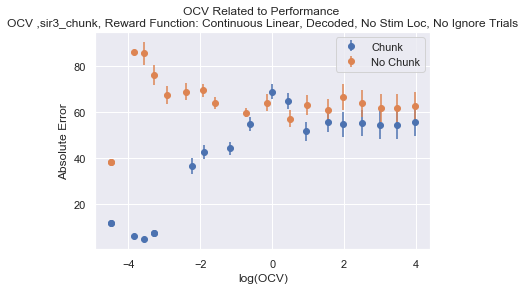

In [12]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
plot_ocv_two(base1,base2, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:220: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


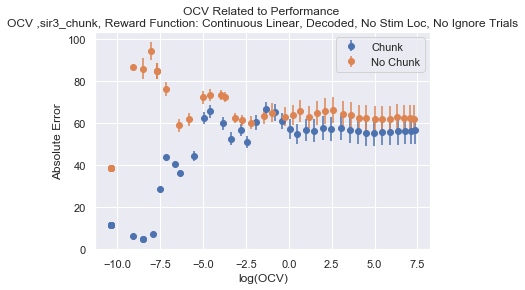

In [16]:
base2 = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
plot_ocv_two(base1,base2)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:220: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


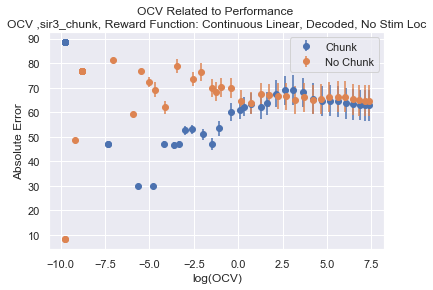

In [14]:
base2 = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/"
base1= "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/"
plot_ocv_two(base1,base2, var = 'diff')

In [15]:
base2 = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
plot_ocv_two(base1,base2, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:220: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


KeyboardInterrupt: 

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:220: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


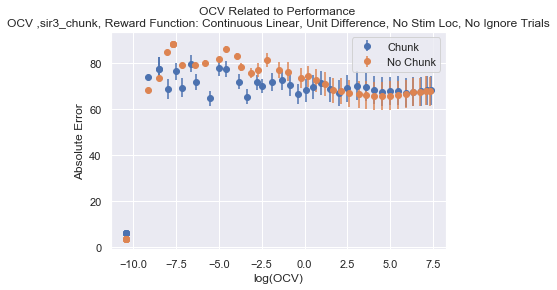

In [10]:
base2 = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/contNoStimLoc/NoIgnore/"
base1= "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/contNoStimLoc/NoIgnore/"
plot_ocv_two(base1,base2, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:220: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


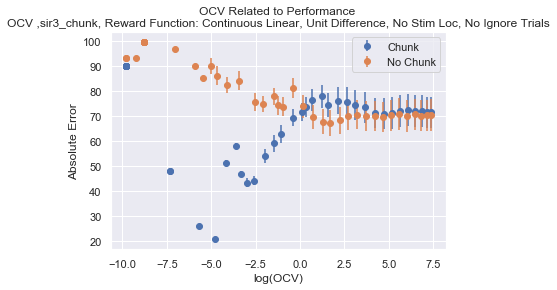

In [9]:
base2 = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/contNoStimLoc/"
base1= "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/contNoStimLoc/"
plot_ocv_two(base1,base2, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:169: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


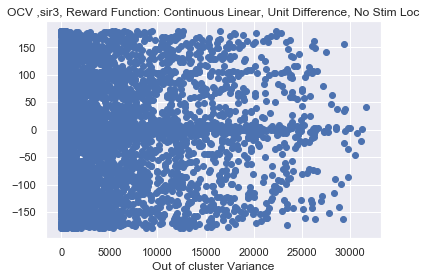

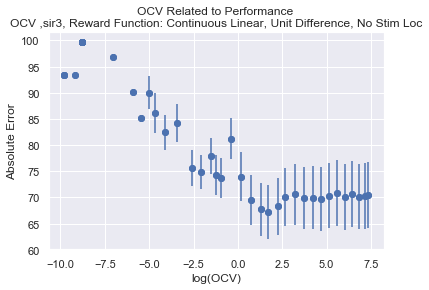

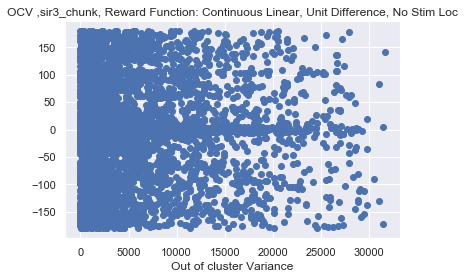

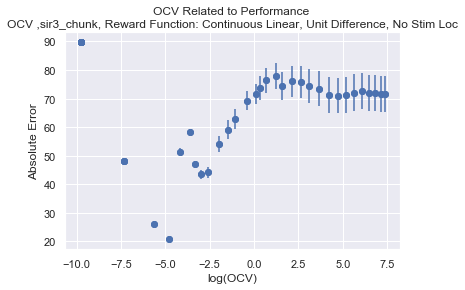

In [48]:
base = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/contNoStimLoc/"
plot_ocv(base, var = 'diff')
base = "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/contNoStimLoc/"
plot_ocv(base, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:169: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


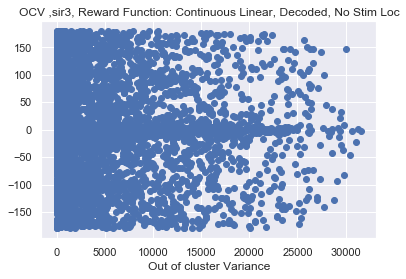

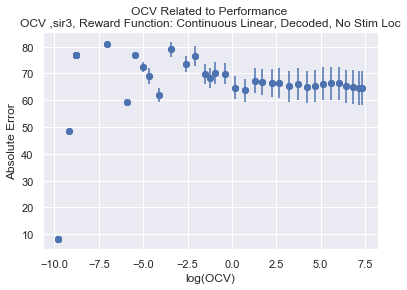

In [47]:
base = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/"
plot_ocv(base, var = 'diff')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:169: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


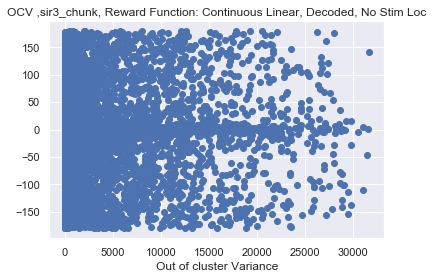

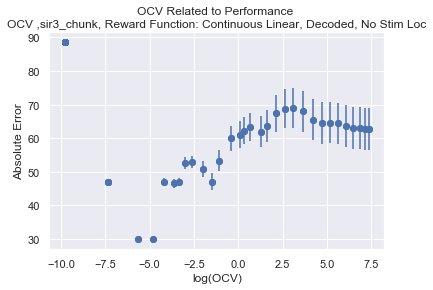

In [46]:
base = "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/"
plot_ocv(base, var = 'diff')

within subject error bars - correction for variance betweeen subjects (between models)
plotting the slope of each ind. model - slope should be nonzero. 
--> or more models. 